Purpose: Find CAM genes in all maSigPro results (time-structured genes for *Y. aloifolia, Y. filamentosa,* and all three CAM physiologies of *Y. gloriosa*.<br>
Author: Anna Pardo<br>
Date initiated: Apr. 21, 2026

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load CAM annotation
camannot = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [3]:
# load TS gene dataframes 
c3cam = pd.read_csv("./C3+CAM_TSgenes_9gt.txt",sep="\t",header="infer")
cam = pd.read_csv("./CAM_TSgenes_9gt.txt",sep="\t",header="infer")
faccam = pd.read_csv("./facCAM_TSgenes_9gt.txt",sep="\t",header="infer")

In [4]:
# load parental TS genes
yats = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/Ya_hclust_k6_clusters.txt",
                  sep="\t",header="infer")
yfts = pd.read_csv("./Yf_3reps_masigpro_clusters.txt",
                  sep="\t",header="infer")

In [5]:
yats["subgenome"] = "Ya"
yats["physiology"] = "CAM"
yats["species"] = "aloifolia"

In [6]:
yfts["subgenome"] = "Yf"
yfts["physiology"] = "C3"
yfts["species"] = "filamentosa"

In [7]:
yats.drop("cluster",axis=1,inplace=True)
yfts.drop("cluster",axis=1,inplace=True)

In [8]:
c3cam["species"] = "gloriosa"
cam["species"] = "gloriosa"
faccam["species"] = "gloriosa"

In [9]:
allts = pd.concat([yats,yfts,c3cam,cam,faccam])

In [10]:
allts.head()

,GeneID,subgenome,physiology,species
0,Yucal.01G000500.v2.1,Ya,CAM,aloifolia
1,Yucal.01G000900.v2.1,Ya,CAM,aloifolia
2,Yucal.01G001300.v2.1,Ya,CAM,aloifolia
3,Yucal.01G001400.v2.1,Ya,CAM,aloifolia
4,Yucal.01G002500.v2.1,Ya,CAM,aloifolia


In [11]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [12]:
# merge with CAM genes
tscamgenes = allts.merge(camannot)
tscamgenes.head()

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
0,Yucal.01G165600.v2.1,Ya,CAM,aloifolia,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1
1,Yucal.03G120900.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1
2,Yucal.05G198500.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_3
3,Yucal.12G110300.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
4,Yucal.12G110300.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1


In [13]:
# how many TS CAM genes in each species - physiology group?
tscamgenes.groupby(["species","physiology"]).count().reset_index()[["species","physiology","GeneID"]]

,species,physiology,GeneID
0,aloifolia,CAM,6
1,filamentosa,C3,2
2,gloriosa,C3+CAM,4
3,gloriosa,CAM,4
4,gloriosa,facultative_CAM,5


In [14]:
len(tscamgenes.index)

21

In [15]:
tscamgenes[tscamgenes["species"]=="aloifolia"]

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
0,Yucal.01G165600.v2.1,Ya,CAM,aloifolia,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1
1,Yucal.03G120900.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1
2,Yucal.05G198500.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_3
3,Yucal.12G110300.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
6,Yucal.12G110500.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_2
10,Yucal.12G110700.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_3


In [16]:
tscamgenes[tscamgenes["species"]=="filamentosa"]

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
14,YufilH1032169m.g,Yf,C3,filamentosa,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,Yf_PPCK_2
15,YufilH1062820m.g,Yf,C3,filamentosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_1


In [17]:
tscamgenes[tscamgenes["species"]=="gloriosa"].sort_values(by="physiology")

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
4,Yucal.12G110300.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
7,Yucal.12G110500.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_2
11,Yucal.12G110700.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_3
16,YufilH1062820m.g,Yf,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_1
5,Yucal.12G110300.v2.1,Ya,CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
8,Yucal.12G110500.v2.1,Ya,CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_2
12,Yucal.12G110700.v2.1,Ya,CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_3
17,YufilH1062820m.g,Yf,CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_1
9,Yucal.12G110500.v2.1,Ya,facultative_CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_2
13,Yucal.12G110700.v2.1,Ya,facultative_CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_3


In [18]:
# save this as a nice table
## first drop some columns
tab = tscamgenes[["species","physiology","gene_abbr_unique"]]
tab.head()

,species,physiology,gene_abbr_unique
0,aloifolia,CAM,Ya_bCA1234_1
1,aloifolia,CAM,Ya_NAD-MDH-cp_1
2,aloifolia,CAM,Ya_NAD-MDH-cp_3
3,aloifolia,CAM,Ya_PPDK_1
4,gloriosa,C3+CAM,Ya_PPDK_1


In [19]:
tab.to_csv("./ts_camgenes_table.csv",sep=",",header=True,index=False)

In [20]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [21]:
camannot[camannot["gene_abbr"]=="PPDK"]

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
37,Yucal.12G110300.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1,Ya
38,Yucal.12G110500.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_2,Ya
39,Yucal.12G110700.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_3,Ya
77,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_1,Yf
78,YufilH1062825m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Yf_PPDK_2,Yf


In [22]:
len(tscamgenes["GeneID"].unique())

10

In [23]:
tscamgenes["gene_abbr"].unique()

array(['bCA1234', 'NAD-MDH-cp', 'PPDK', 'PPCK', 'BPPC'], dtype=object)

## Are these time-structured CAM genes also DE?

In [24]:
# load maSigPro DE results - parents
yade = list(pd.read_csv("./Ya_DEGs_masigpro.txt",sep="\t",header=None)[0])
yfde = list(pd.read_csv("./Yf_DEGs_masigpro.txt",sep="\t",header=None)[0])

In [25]:
tscamgenes.head()

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
0,Yucal.01G165600.v2.1,Ya,CAM,aloifolia,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1
1,Yucal.03G120900.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1
2,Yucal.05G198500.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_3
3,Yucal.12G110300.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
4,Yucal.12G110300.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1


In [26]:
# for each species: get a list of the time-structured CAM gene IDs & check if they are in the DEG list
def ts_de_compare(sp,delist):
    sub = tscamgenes[tscamgenes["species"]==sp]
    tslist = list(sub["GeneID"])
    intlist = list(set(tslist).intersection(set(delist)))
    if len(intlist)==0:
        return "No overlap"
    else:
        df = sub[sub["GeneID"].isin(intlist)]
        return list(df["gene_abbr_unique"])

In [27]:
ts_de_compare("aloifolia",yade)

['Ya_NAD-MDH-cp_3']

In [28]:
ts_de_compare("filamentosa",yfde)

['Yf_PPCK_2', 'Yf_PPDK_1']

In [29]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [30]:
# are there other CAM genes (not identified as TS) in the parental DE sets?
def camde(delist,ann=camannot):
    sub = ann[ann["GeneID"].isin(delist)]
    return list(sub["gene_abbr_unique"])

In [31]:
camde(yfde)

['Yf_PPCK_2', 'Yf_PPDK_1']

In [32]:
camde(yade)

['Ya_NAD-MDH-cp_3']

In [33]:
# load DEG lists (by data subset overlap) for each of the three physiologies
camde = json.load(open("./CAM_DEGs_by_x_overlap.json"))
c3de = json.load(open("./C3+CAM_DEGs_by_x_overlap.json"))
facde = json.load(open("./facCAM_DEGs_by_x_overlap.json"))

In [34]:
tscamgenes.head()

,GeneID,subgenome,physiology,species,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique
0,Yucal.01G165600.v2.1,Ya,CAM,aloifolia,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1
1,Yucal.03G120900.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1
2,Yucal.05G198500.v2.1,Ya,CAM,aloifolia,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_3
3,Yucal.12G110300.v2.1,Ya,CAM,aloifolia,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1
4,Yucal.12G110300.v2.1,Ya,C3+CAM,gloriosa,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,Ya_PPDK_1


In [35]:
def deint_in_x(dedict,x,phys):
    df = tscamgenes[(tscamgenes["species"]=="gloriosa") & (tscamgenes["physiology"]==phys)]
    glist = list(df["GeneID"])
    delist = dedict[x]
    intlist = list(set(glist).intersection(set(delist)))
    intdf = df[df["GeneID"].isin(intlist)]
    return list(intdf["gene_abbr_unique"])

In [36]:
deint_in_x(facde,"3","facultative_CAM")

['Ya_PPDK_2', 'Ya_PPDK_3', 'Yf_PPDK_1', 'Ya_BPPC_2', 'Ya_BPPC_3']

## Plot TPM profiles of TS (and maybe also non-TS, for comparison) CAM genes

In [37]:
# load Yg TPM
mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_561/2639278733.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [38]:
# load parental TPM
yatpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",sep="\t",header="infer")
yftpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",sep="\t",header="infer")

In [39]:
yftpm.head()

,sample_name,genotype,time,treat,ZT,species,YufilH1000001m.g,YufilH1000003m.g,YufilH1000007m.g,YufilH1000011m.g,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,X73,2.0,4.0,D,13.0,filamentosa,0.0,69.209532,18.118388,14.647685,...,0.000000,8.398514,73.738130,2.102850,19.402193,20.453314,8.251751,16.330160,0.0,0.000000
1,X74,2.0,5.0,D,17.0,filamentosa,0.0,89.139056,20.331585,15.566820,...,0.000000,6.640828,72.812930,2.554231,22.485396,15.573745,7.444941,19.426909,0.0,1.679625
2,X64,2.0,2.0,W,5.0,filamentosa,0.0,40.700085,8.461118,16.711576,...,0.000000,11.801415,102.629400,1.869051,29.032564,16.676626,5.797593,8.062388,0.0,0.000000
3,X101,27.0,3.0,D,9.0,filamentosa,0.0,48.314400,23.459476,18.753399,...,0.000000,12.020853,74.562204,2.408896,19.987492,27.106460,5.948658,7.219606,0.0,1.085844
4,X102,27.0,1.0,D,1.0,filamentosa,0.0,58.172755,23.191529,14.185471,...,0.575726,6.796891,51.324403,1.323844,22.161740,4.797914,2.791854,27.798525,0.0,0.000000


In [40]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [41]:
phys = json.load(open("../physiology/physiological_categories_from_TA.json"))

In [42]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [43]:
mdtpm["CAM physiology"] = mdtpm["genotype"].map(phys)

In [44]:
mdtpm["CAM physiology"].unique()

array(['C3+CAM', 'facultative CAM', 'CAM', nan], dtype=object)

In [45]:
yatpm["CAM physiology"] = "CAM"
yftpm["CAM physiology"] = "C3"

In [46]:
genes = list(tscamgenes["gene_abbr_unique"].unique())

In [47]:
genes

['Ya_bCA1234_1',
 'Ya_NAD-MDH-cp_1',
 'Ya_NAD-MDH-cp_3',
 'Ya_PPDK_1',
 'Ya_PPDK_2',
 'Ya_PPDK_3',
 'Yf_PPCK_2',
 'Yf_PPDK_1',
 'Ya_BPPC_2',
 'Ya_BPPC_3']

In [48]:
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [49]:
yftpm.head()

,sample_name,genotype,time,treat,ZT,species,YufilH1000001m.g,YufilH1000003m.g,YufilH1000007m.g,YufilH1000011m.g,...,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g,CAM physiology
0,X73,2.0,4.0,D,13.0,filamentosa,0.0,69.209532,18.118388,14.647685,...,8.398514,73.738130,2.102850,19.402193,20.453314,8.251751,16.330160,0.0,0.000000,C3
1,X74,2.0,5.0,D,17.0,filamentosa,0.0,89.139056,20.331585,15.566820,...,6.640828,72.812930,2.554231,22.485396,15.573745,7.444941,19.426909,0.0,1.679625,C3
2,X64,2.0,2.0,W,5.0,filamentosa,0.0,40.700085,8.461118,16.711576,...,11.801415,102.629400,1.869051,29.032564,16.676626,5.797593,8.062388,0.0,0.000000,C3
3,X101,27.0,3.0,D,9.0,filamentosa,0.0,48.314400,23.459476,18.753399,...,12.020853,74.562204,2.408896,19.987492,27.106460,5.948658,7.219606,0.0,1.085844,C3
4,X102,27.0,1.0,D,1.0,filamentosa,0.0,58.172755,23.191529,14.185471,...,6.796891,51.324403,1.323844,22.161740,4.797914,2.791854,27.798525,0.0,0.000000,C3


In [50]:
# ---------------------------------------------------------
# Build long-format TPM dataframe for all genes in family
# ---------------------------------------------------------
def plottpm_genefamily(tpm, genefam, camdf=camannot, add_phys=True):
    
    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    # genes present in this TPM matrix
    genes = [g for g in fam["GeneID"].unique() if g in tpm.columns]

    if len(genes) == 0:
        return pd.DataFrame()

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    # map metadata
    subdict = fam.set_index("GeneID")["subgenome"].to_dict()
    namedict = fam.set_index("GeneID")["gene_abbr_unique"].to_dict()

    plong["subgenome"] = plong["GeneID"].map(subdict)
    plong["genename"] = plong["GeneID"].map(namedict)

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong


# ---------------------------------------------------------
# Global consistent style map across all 5 panels
# ---------------------------------------------------------
def build_family_stylemaps(genefam, camdf=camannot):

    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    genes = fam["gene_abbr_unique"].unique().tolist()

    palette = sns.color_palette("tab10", n_colors=max(len(genes), 3))
    color_map = dict(zip(genes, palette))

    subgenes = fam["subgenome"].unique().tolist()

    # VALID seaborn dash patterns
    dash_patterns = [
        "",          # solid
        (4, 2),      # dashed
        (1, 1),      # dotted
        (6, 2, 1, 2) # dash-dot
    ]

    style_map = {
        sg: dash_patterns[i % len(dash_patterns)]
        for i, sg in enumerate(subgenes)
    }

    return color_map, style_map


# ---------------------------------------------------------
# Generic panel plotting function
# ---------------------------------------------------------
def plot_profile(df, ax, title, color_map, style_map,
                 log=False, fontsize=18):

    if df.empty:
        ax.set_title(title, fontsize=fontsize)
        return

    plotdf = df.copy()

    ycol = "TPM"

    if log:
        plotdf["logTPM"] = np.log1p(plotdf["TPM"])
        ycol = "logTPM"

    sns.lineplot(
        data=plotdf,
        x="ZT",
        y=ycol,
        hue="genename",
        style="subgenome",
        palette=color_map,
        dashes=style_map,
        estimator="mean",
        errorbar=None,
        lw=2,
        ax=ax
    )

    # dark period shading
    t = np.arange(0, 25)
    ax.fill_between(
        t, 0, 1,
        where=t >= 12,
        color="gray",
        alpha=0.25,
        transform=ax.get_xaxis_transform()
    )

    ax.set_xlim(0, 24)
    ax.set_xticks(sorted(plotdf["ZT"].unique()))
    ax.set_xlabel("")
    ax.set_ylabel("TPM")
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=14)


In [51]:
def plot_genefam_withparents(genefam, d="./", save=True, log=False):

    # -----------------------------
    # load data
    # -----------------------------
    yaplot = plottpm_genefamily(yatpm, genefam, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, genefam, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, genefam, add_phys=True)

    # -----------------------------
    # NEW physiology categories
    # -----------------------------
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # -----------------------------
    # style maps
    # -----------------------------
    color_map, style_map = build_family_stylemaps(genefam)

    # -----------------------------
    # figure
    # -----------------------------
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(28, 6),
        sharey=True
    )

    plot_profile(
        yfplot, ax[0],
        "Y. filamentosa (C3 parent)",
        color_map, style_map, log, 18
    )

    plot_profile(
        c3, ax[1],
        f"C3+CAM genotypes (n={c3gt})",
        color_map, style_map, log, 18
    )

    plot_profile(
        fac, ax[2],
        f"Facultative CAM genotypes (n={facgt})",
        color_map, style_map, log, 18
    )

    plot_profile(
        cam, ax[3],
        f"CAM genotypes (n={camgt})",
        color_map, style_map, log, 18
    )

    plot_profile(
        yaplot, ax[4],
        "Y. aloifolia (CAM parent)",
        color_map, style_map, log, 18
    )

    # -----------------------------
    # unify y-axis
    # -----------------------------
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # -----------------------------
    # one shared legend
    # -----------------------------
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=min(len(labels), 6),
        bbox_to_anchor=(1, 1.1),
        fontsize=14
    )

    plt.suptitle(genefam, fontsize=24)
    fig.tight_layout()

    if save:
        base = os.path.join(d, f"allgt_withparents_{genefam}_profiles_byphys")
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

In [52]:
genefams = list(tscamgenes["gene_abbr"].unique())

In [53]:
genefams

['bCA1234', 'NAD-MDH-cp', 'PPDK', 'PPCK', 'BPPC']

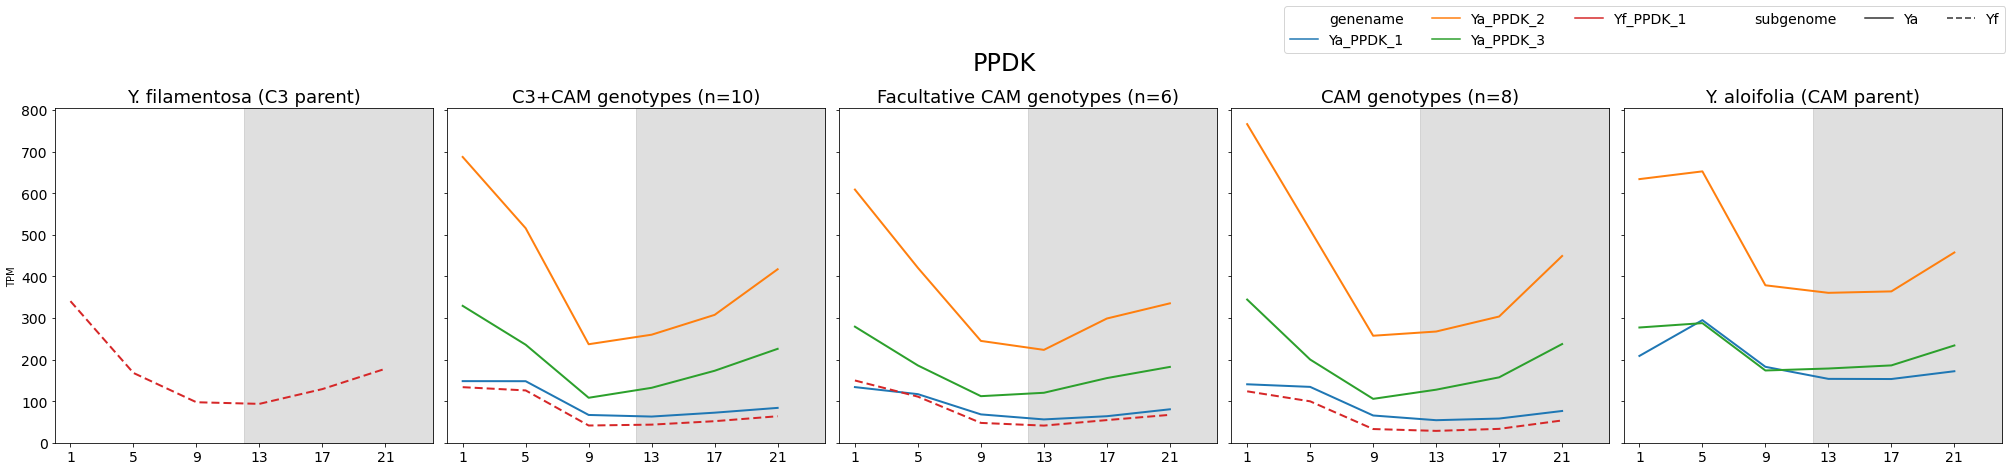

In [54]:
plot_genefam_withparents("PPDK")

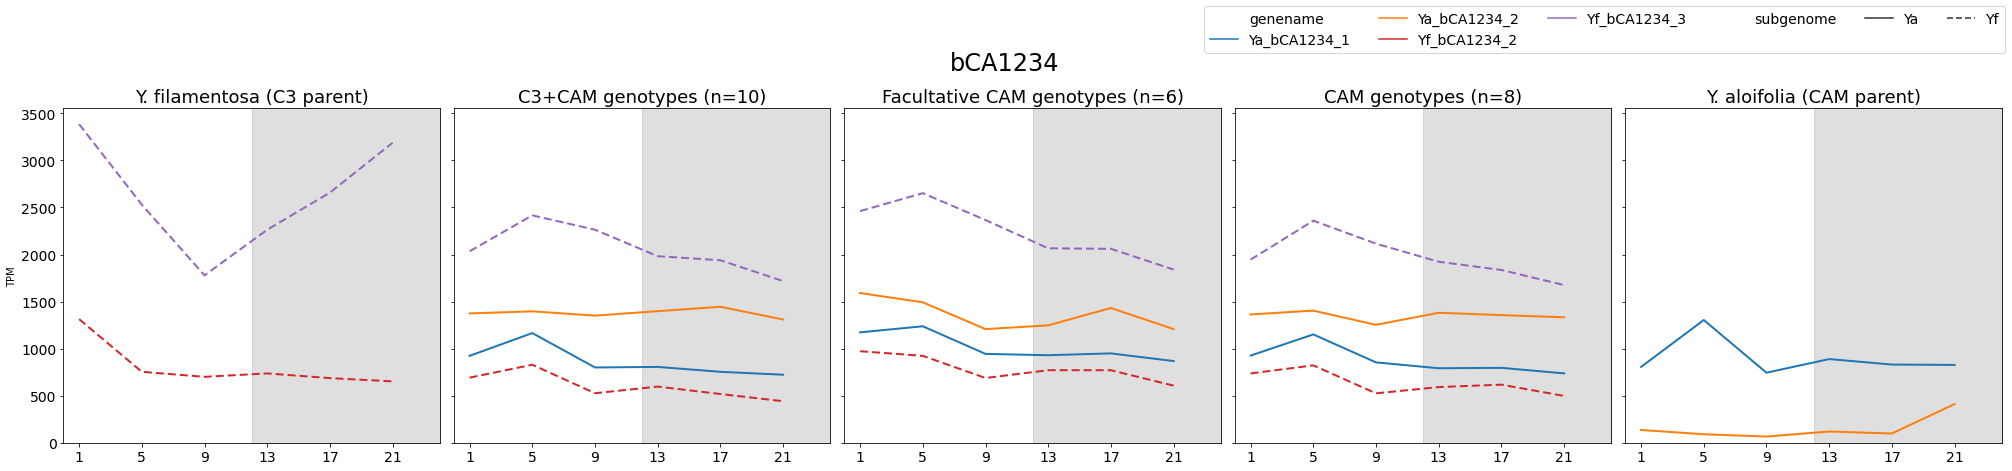

In [55]:
plot_genefam_withparents("bCA1234")

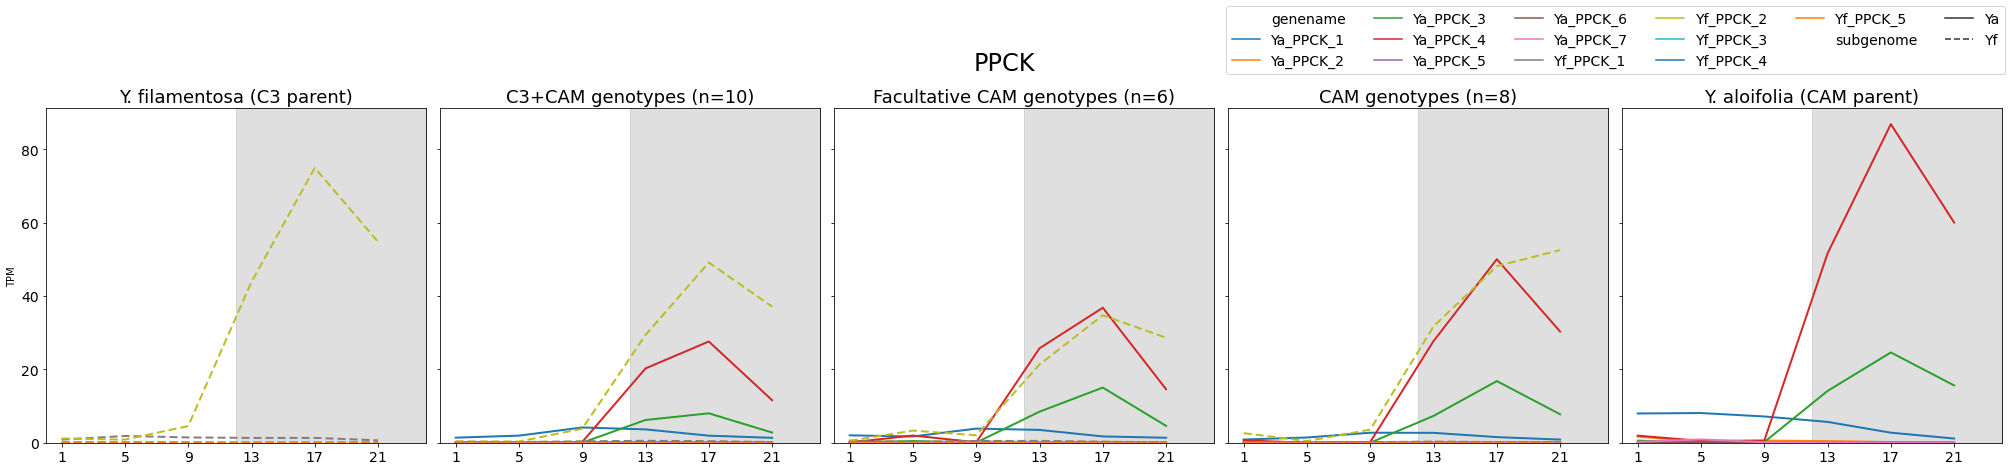

In [56]:
plot_genefam_withparents("PPCK")

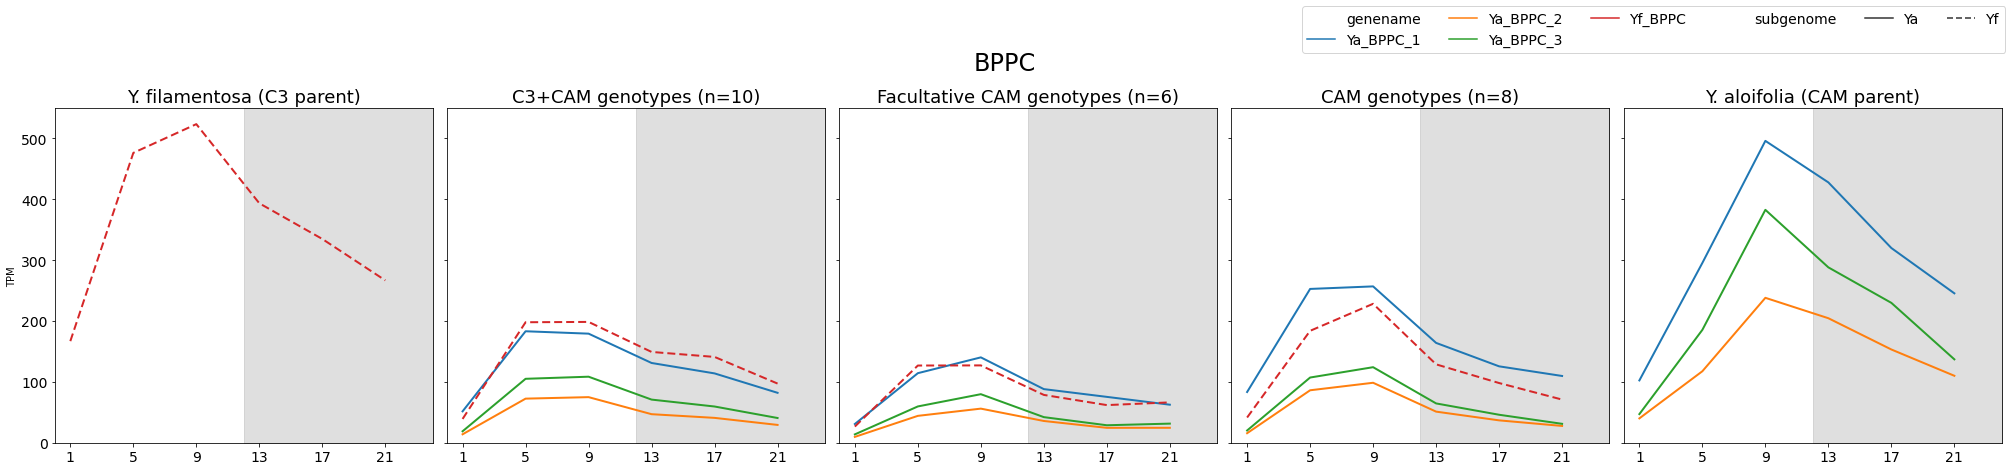

In [57]:
plot_genefam_withparents("BPPC")

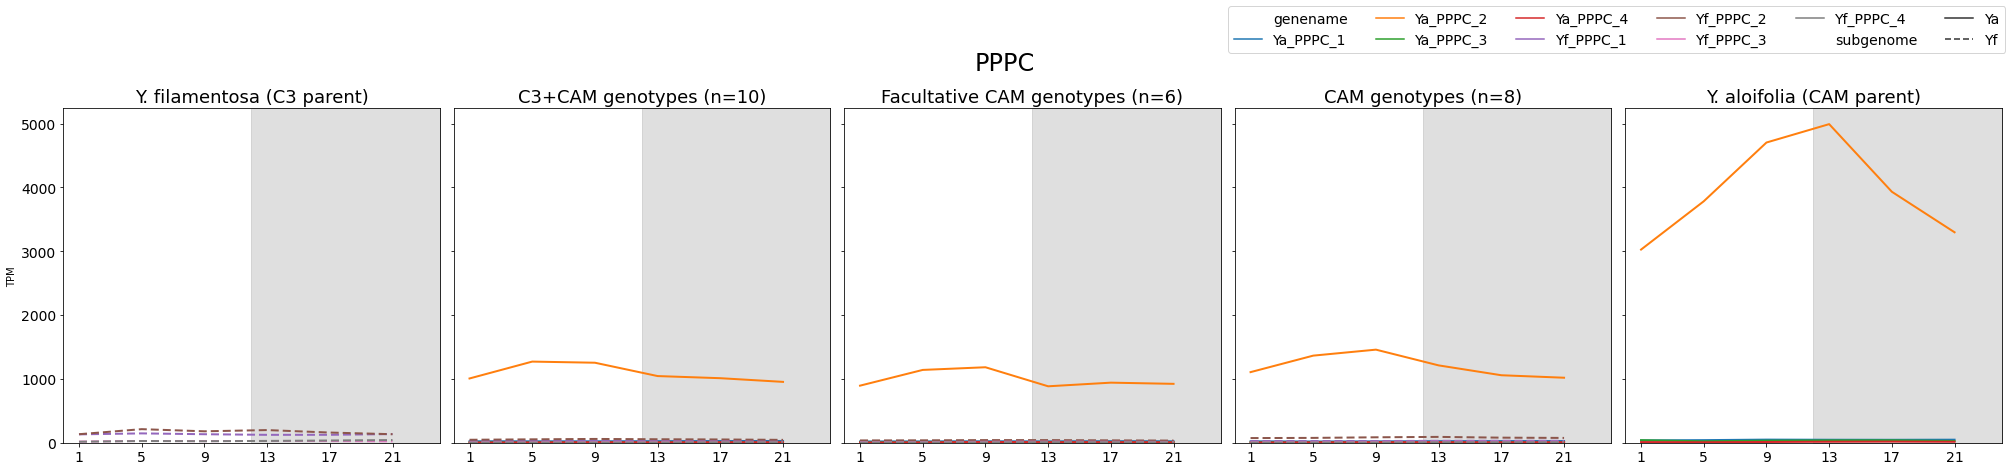

In [58]:
plot_genefam_withparents("PPPC")

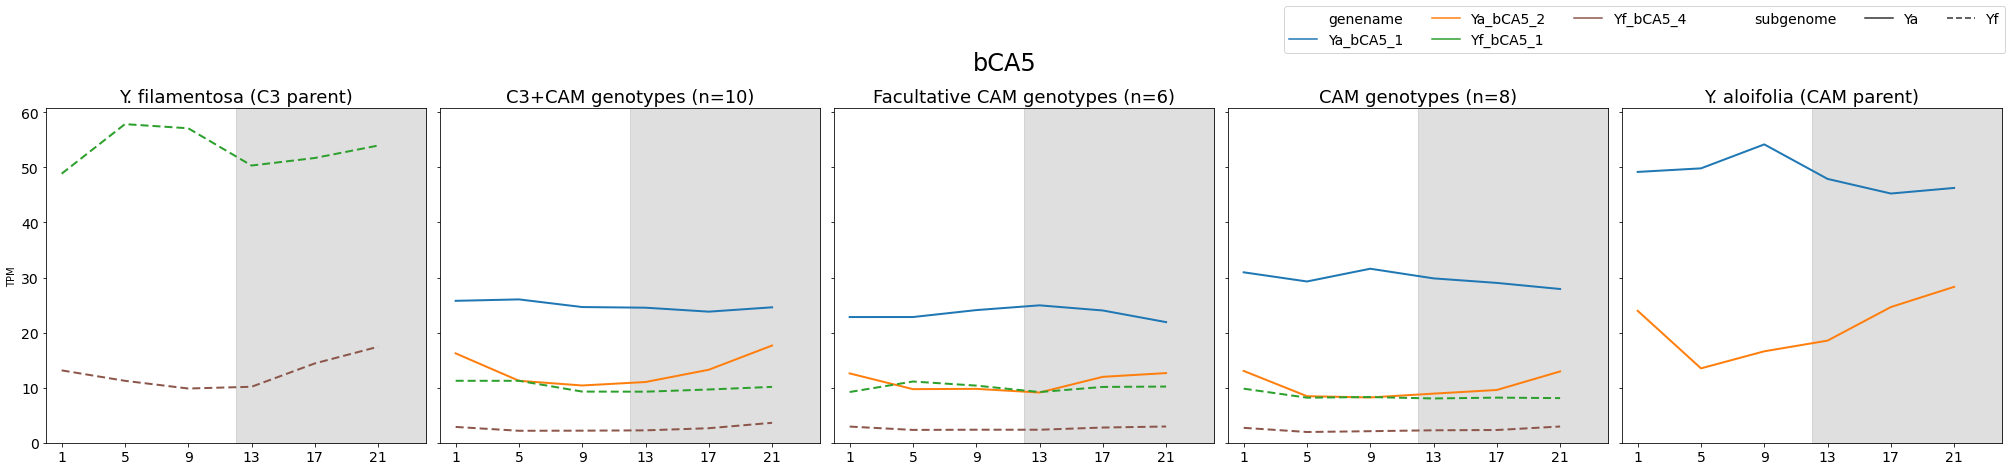

In [59]:
plot_genefam_withparents("bCA5")

In [60]:
camannot["gene_abbr"].unique()

array(['bCA1234', 'bCA5', 'NAD-MDH-cp', 'NAD-MDH-ct', 'NADP-MDH', 'BPPC',
       'PPPC', 'PPCK', 'NAD-ME', 'NADP-ME', 'PEPCK', 'PPDK'], dtype=object)

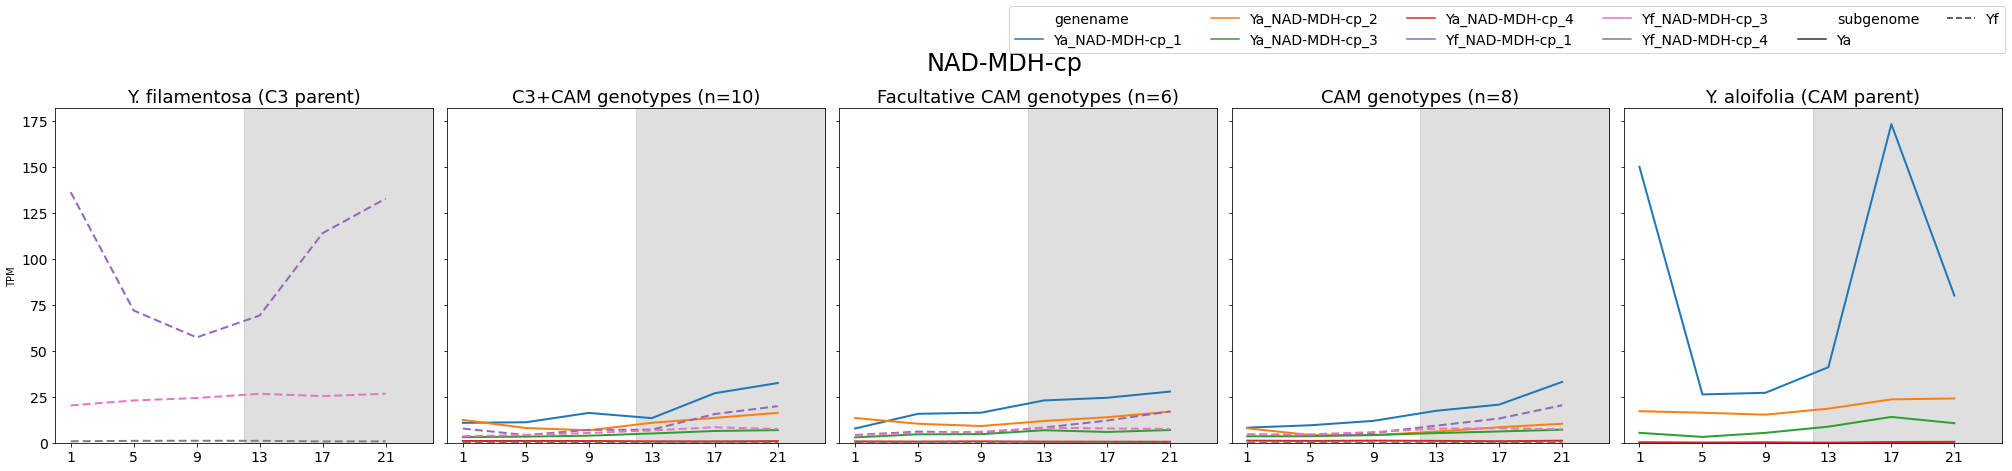

In [61]:
plot_genefam_withparents("NAD-MDH-cp")

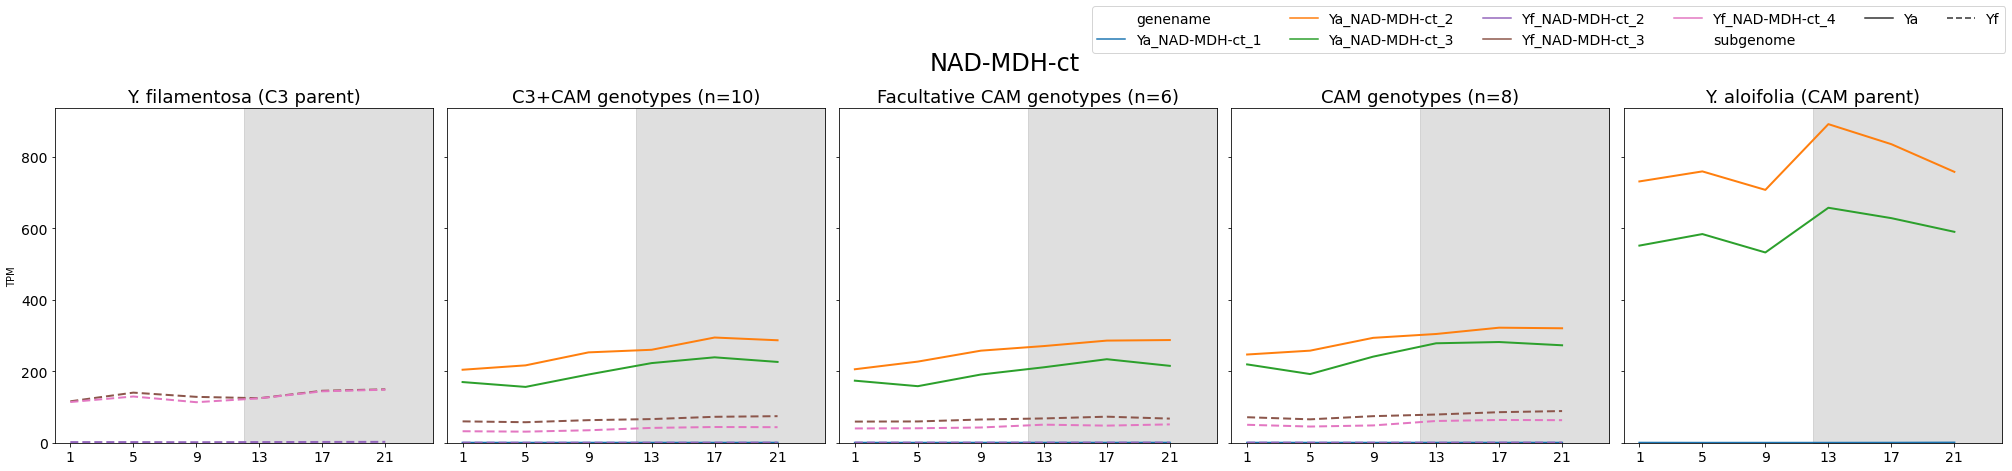

In [62]:
plot_genefam_withparents("NAD-MDH-ct")

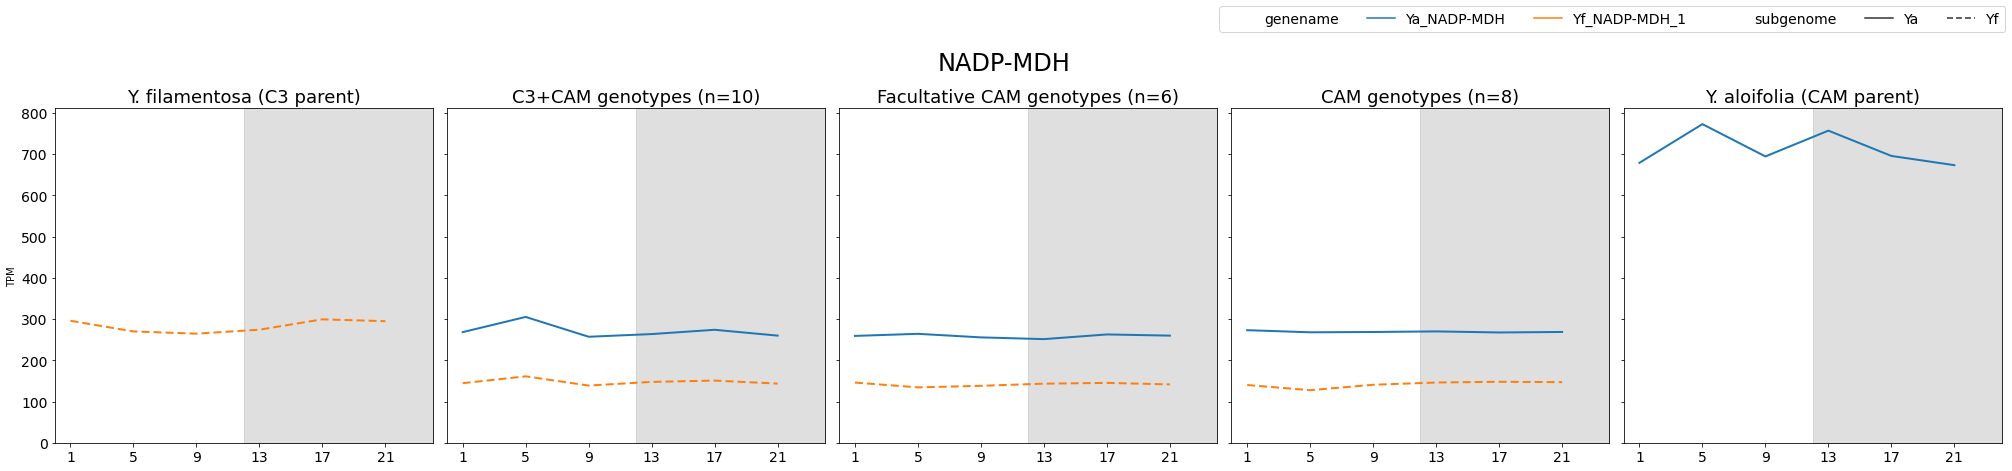

In [63]:
plot_genefam_withparents("NADP-MDH")

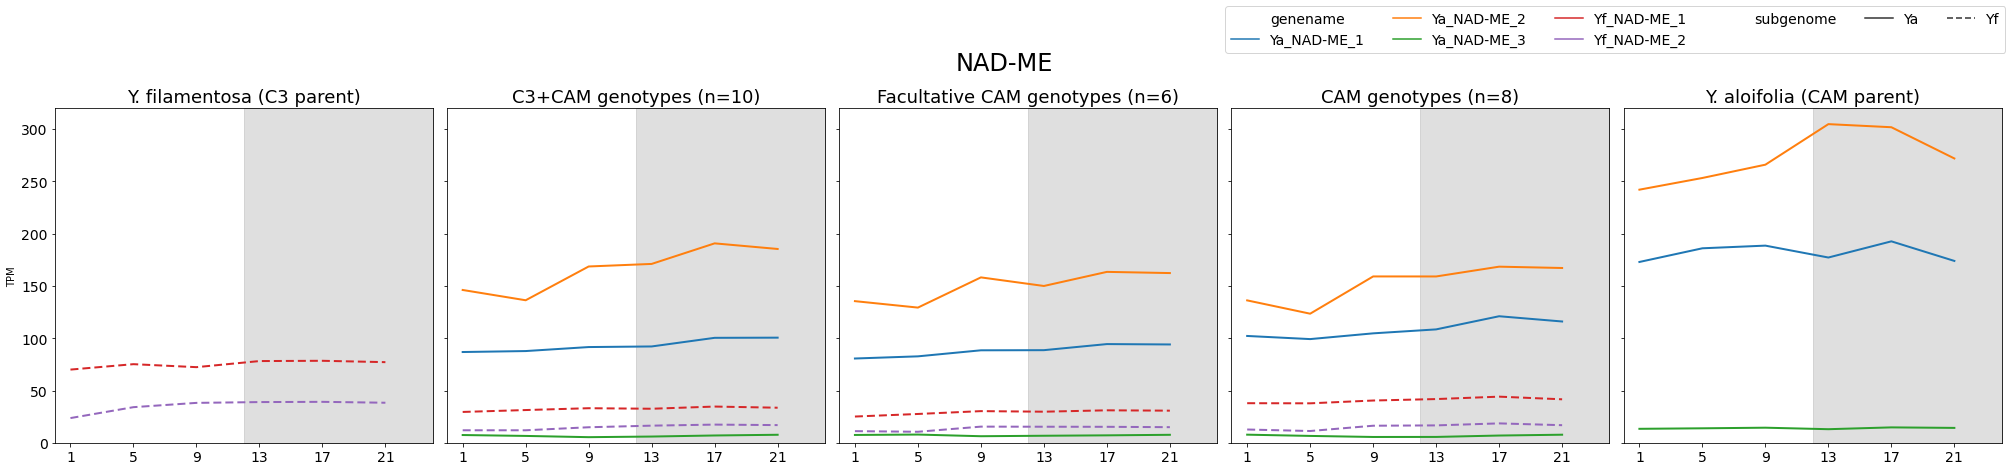

In [64]:
plot_genefam_withparents("NAD-ME")

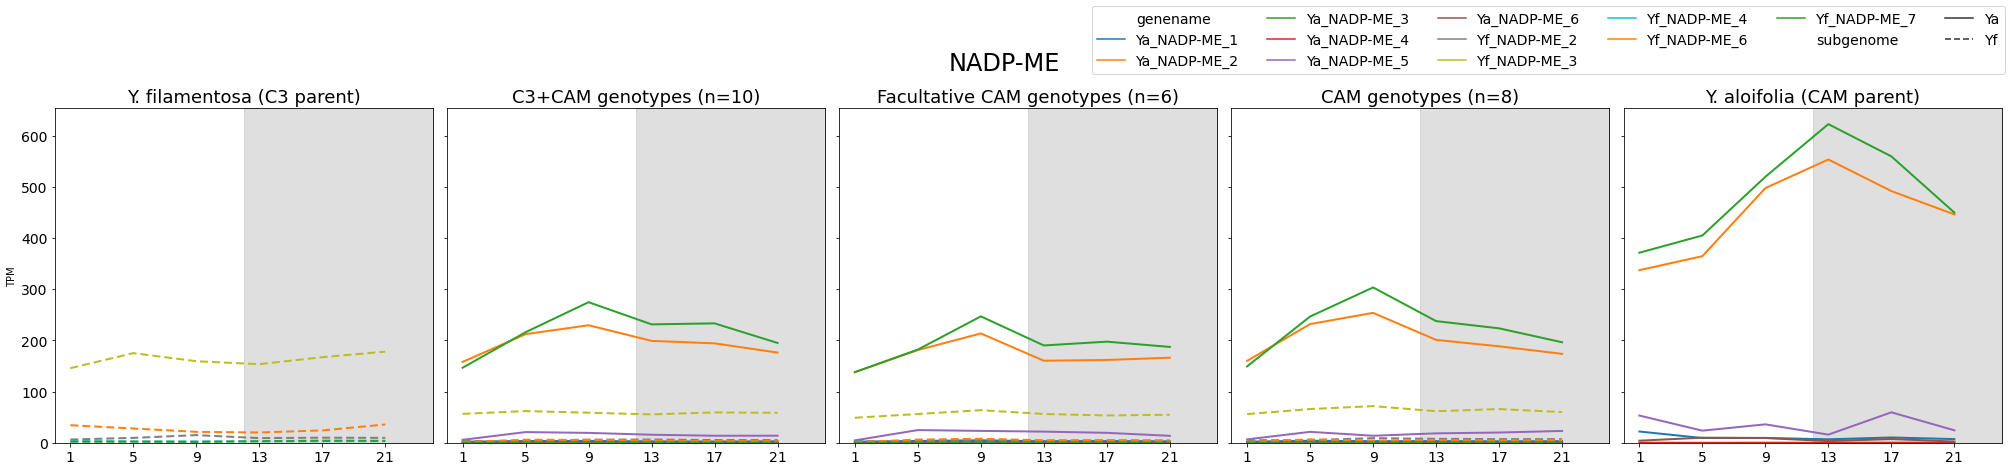

In [65]:
plot_genefam_withparents("NADP-ME")

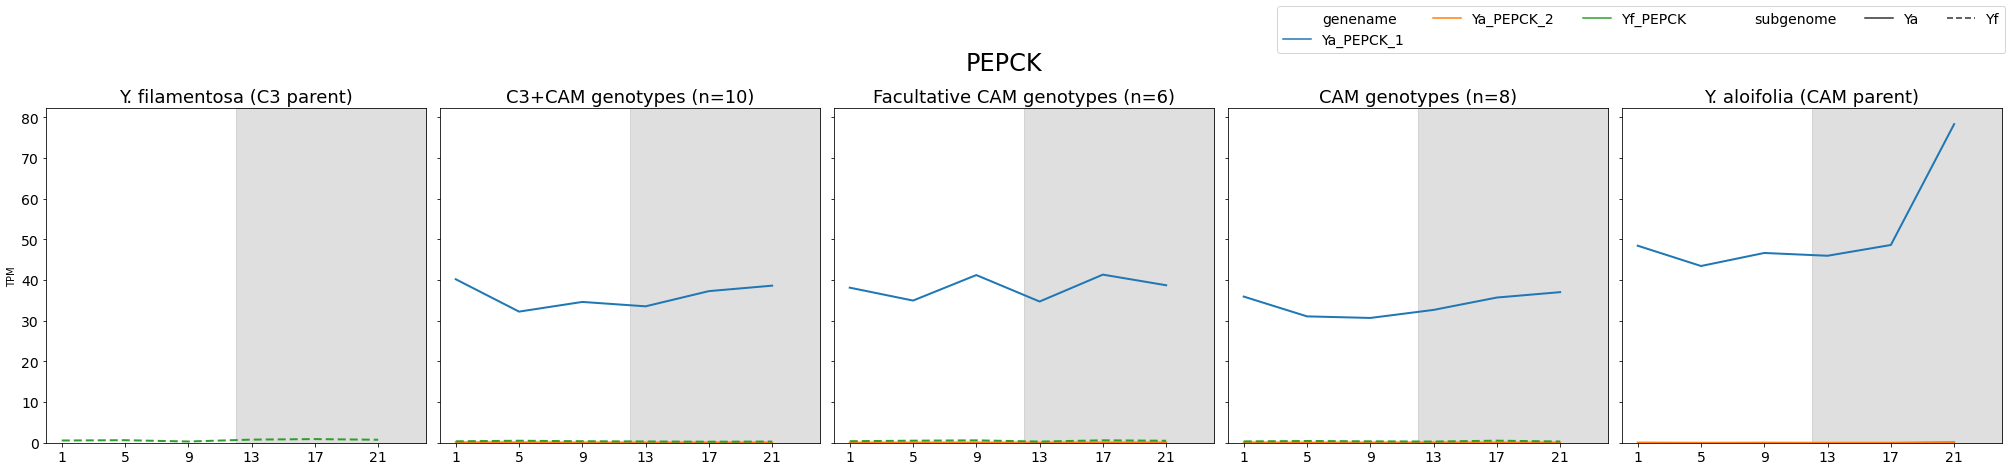

In [66]:
plot_genefam_withparents("PEPCK")

In [67]:
# ---------------------------------------------------------
# Plot each gene separately by treatment
# (color = gene, linestyle = treatment)
# ---------------------------------------------------------

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Build long-format TPM dataframe for all genes in family
# ---------------------------------------------------------
def plottpm_genefamily(tpm, genefam, camdf=camannot, add_phys=True):

    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    genes = [g for g in fam["GeneID"].unique() if g in tpm.columns]

    if len(genes) == 0:
        return pd.DataFrame()

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    namedict = fam.set_index("GeneID")["gene_abbr_unique"].to_dict()
    subdict  = fam.set_index("GeneID")["subgenome"].to_dict()

    plong["genename"] = plong["GeneID"].map(namedict)
    plong["subgenome"] = plong["GeneID"].map(subdict)

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong


# ---------------------------------------------------------
# Color genes consistently across all panels
# ---------------------------------------------------------
def build_family_stylemaps(genefam, camdf=camannot):

    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    genes = fam["gene_abbr_unique"].unique().tolist()

    palette = sns.color_palette("tab10", n_colors=max(len(genes), 3))
    color_map = dict(zip(genes, palette))

    # treatment line styles
    treat_map = {
        "W": "",
        "D": (4, 2)
    }

    return color_map, treat_map


# ---------------------------------------------------------
# Plot one panel
# ---------------------------------------------------------
def plot_profile(df, ax, title, color_map, treat_map,
                 log=False, fontsize=18):

    if df.empty:
        ax.set_title(title, fontsize=fontsize)
        return

    plotdf = df.copy()

    ycol = "TPM"

    if log:
        plotdf["logTPM"] = np.log1p(plotdf["TPM"])
        ycol = "logTPM"

    sns.lineplot(
        data=plotdf,
        x="ZT",
        y=ycol,
        hue="genename",        # each gene gets color
        style="treat",        # treatment gets linestyle
        palette=color_map,
        dashes=treat_map,
        estimator="mean",
        errorbar=None,
        lw=2,
        ax=ax
    )

    # dark period shading
    t = np.arange(0, 25)
    ax.fill_between(
        t, 0, 1,
        where=t >= 12,
        color="gray",
        alpha=0.25,
        transform=ax.get_xaxis_transform()
    )

    ax.set_xlim(0, 24)
    ax.set_xticks(sorted(plotdf["ZT"].unique()))
    ax.set_xlabel("")
    ax.set_ylabel("TPM")
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=14)


# ---------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------
def plot_genefam_withparents(genefam, d="./", save=True, log=False):

    # load data
    yaplot = plottpm_genefamily(yatpm, genefam, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, genefam, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, genefam, add_phys=True)

    # physiology groups
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # style maps
    color_map, treat_map = build_family_stylemaps(genefam)

    # figure
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(30, 6),
        sharey=True
    )

    plot_profile(yfplot, ax[0],
                 "Y. filamentosa (C3 parent)",
                 color_map, treat_map, log, 18)

    plot_profile(c3, ax[1],
                 f"C3+CAM genotypes (n={c3gt})",
                 color_map, treat_map, log, 18)

    plot_profile(fac, ax[2],
                 f"Facultative CAM (n={facgt})",
                 color_map, treat_map, log, 18)

    plot_profile(cam, ax[3],
                 f"CAM genotypes (n={camgt})",
                 color_map, treat_map, log, 18)

    plot_profile(yaplot, ax[4],
                 "Y. aloifolia (CAM parent)",
                 color_map, treat_map, log, 18)

    # unify y-axis
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # legend from middle panel
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1, 1.1),
        ncol=min(len(labels), 6),
        fontsize=14,
        frameon=False
    )

    plt.suptitle(genefam, fontsize=24)
    fig.tight_layout()

    if save:
        base = os.path.join(d, f"{genefam}_profiles_by_treatment")
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

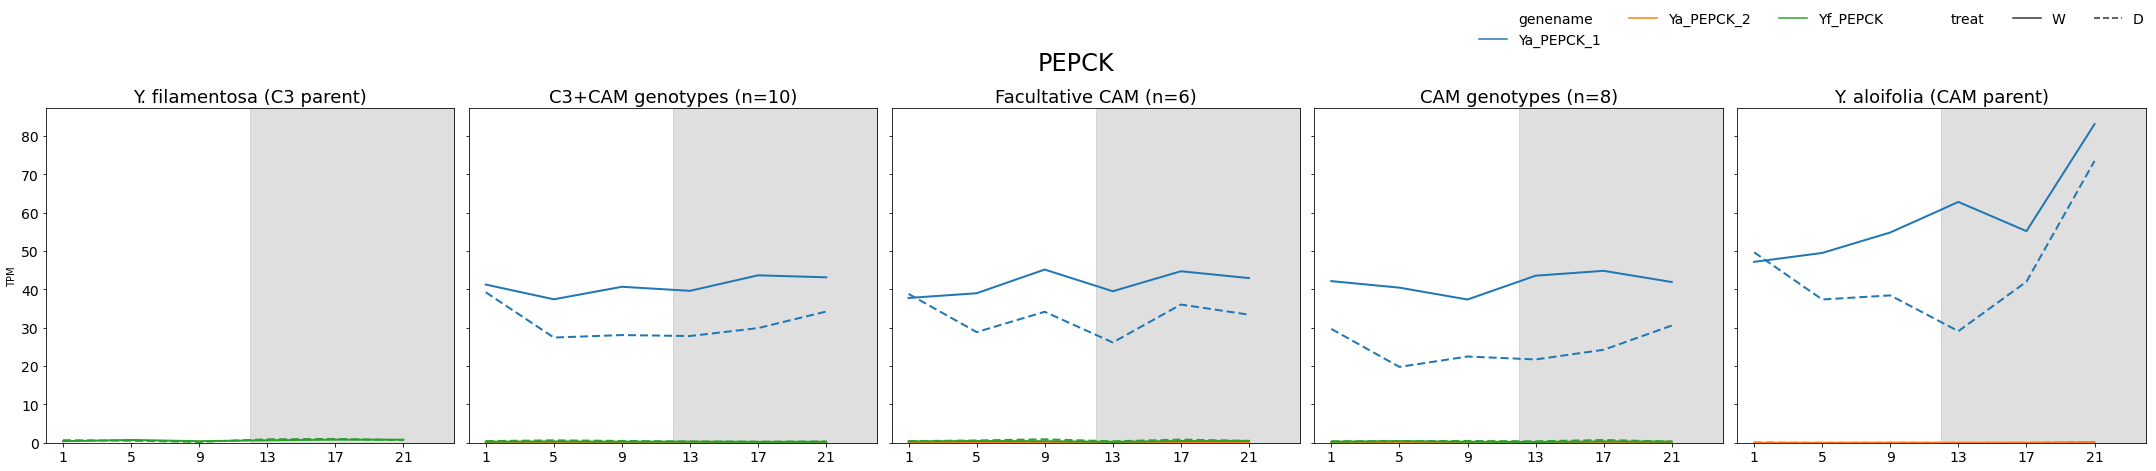

In [68]:
plot_genefam_withparents("PEPCK")

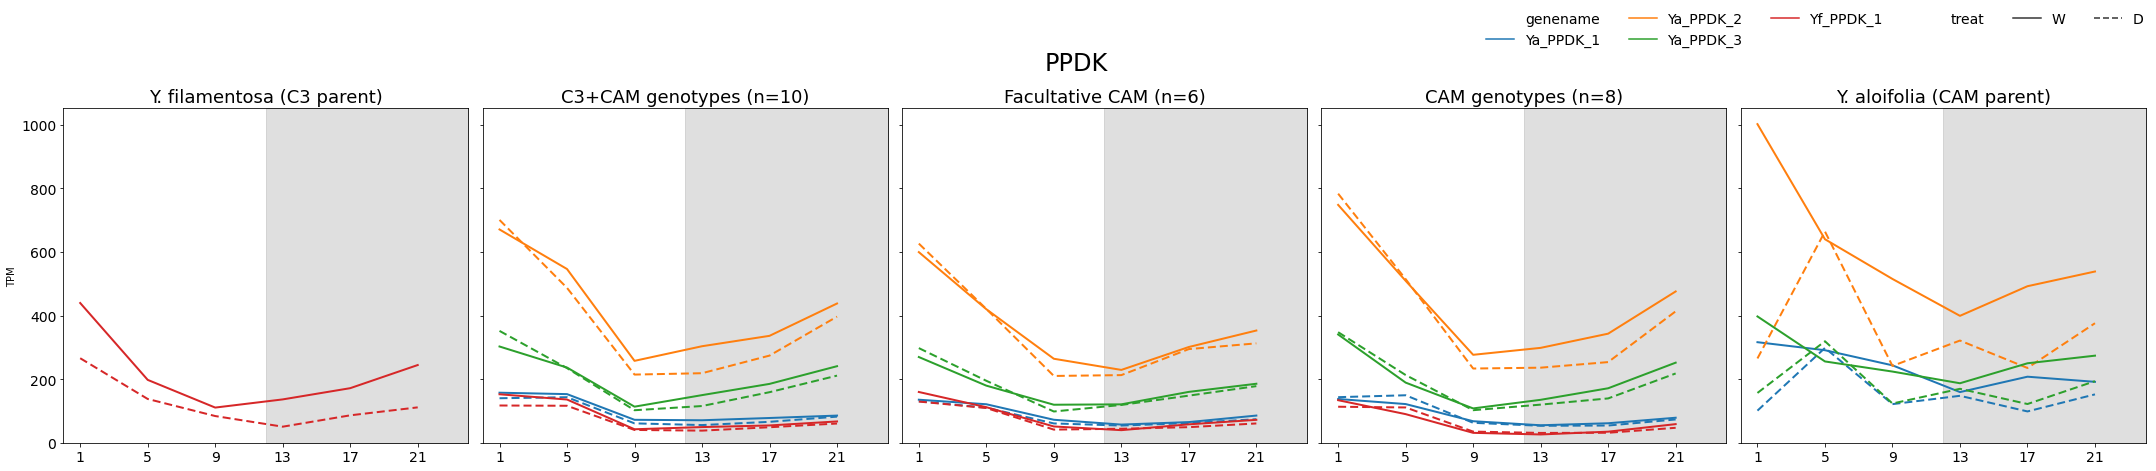

In [69]:
plot_genefam_withparents("PPDK")

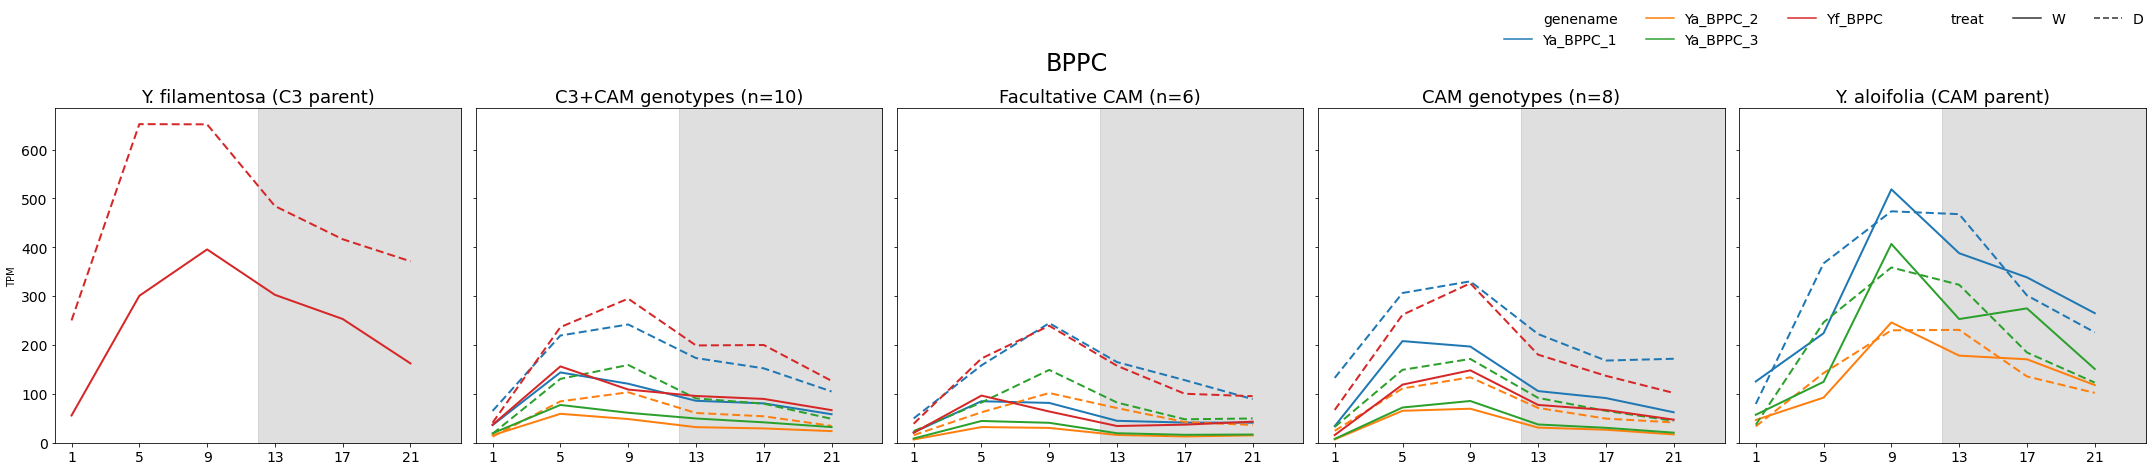

In [70]:
plot_genefam_withparents("BPPC")

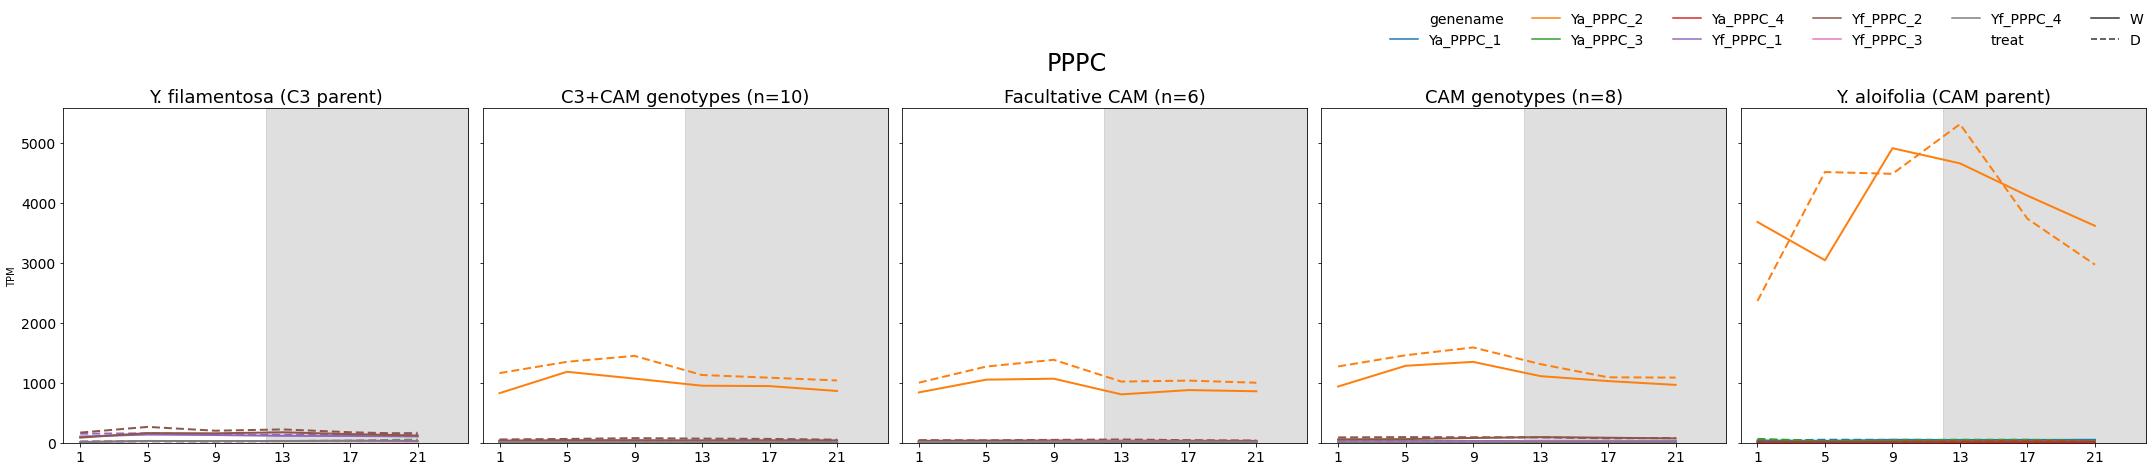

In [71]:
plot_genefam_withparents("PPPC")

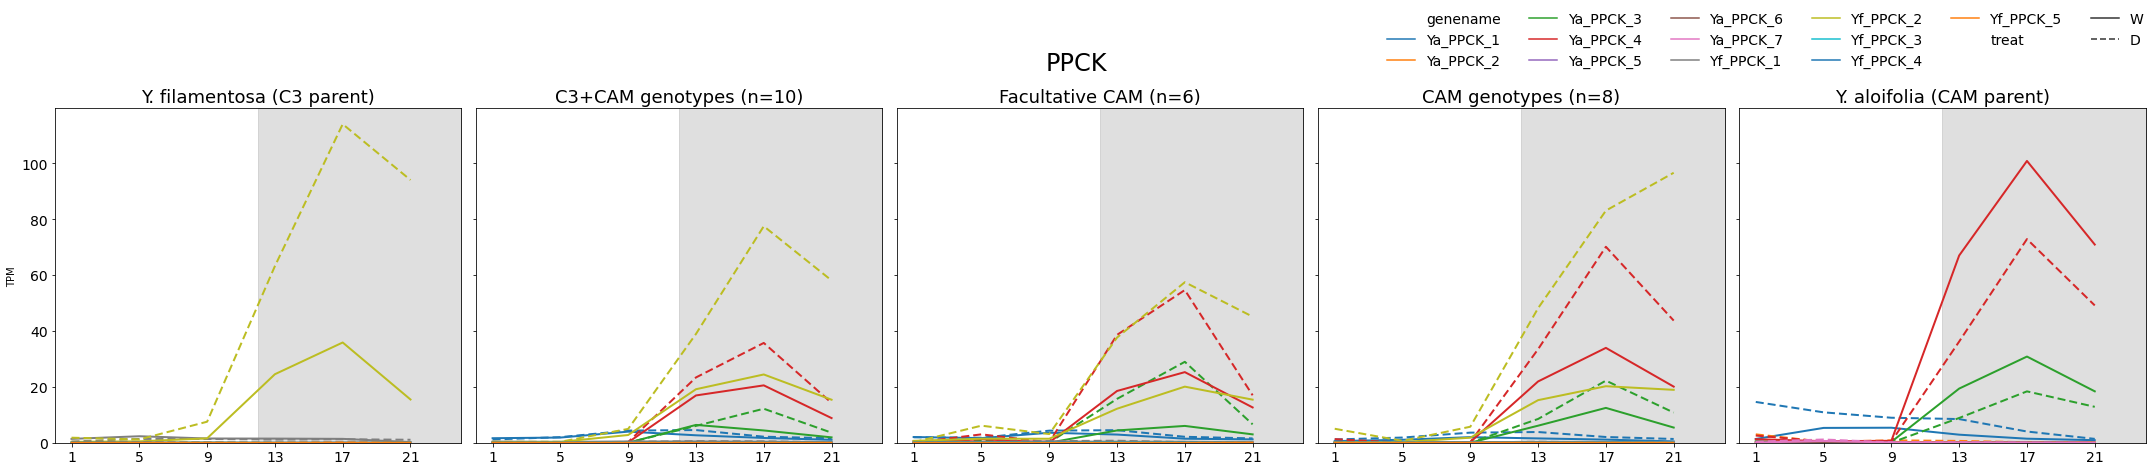

In [72]:
plot_genefam_withparents("PPCK")

## Apr. 29: Plot profiles for gene IDs of interest (from David's paper & prior analyses: HybridExpress & ASE)

In [73]:
# load list of these gene IDs
gids = list(pd.read_csv("../geneIDs_from_Wickelletal_fig3.txt",sep="\t",header=None)[0])

In [74]:
gids

['YufilH1011201m.g',
 'YufilH1032169m.g',
 'YufilH1038083m.g',
 'YufilH1039537m.g',
 'YufilH1044442m.g',
 'YufilH1062820m.g',
 'YufilH1072277m.g',
 'Yucal.02G112700.v2.1',
 'Yucal.06G042800.v2.1',
 'Yucal.07G108300.v2.1',
 'Yucal.16G056000.v2.1',
 'Yucal.06G106600.v2.1',
 'Yucal.12G110500.v2.1',
 'Yucal.05G072500.v2.1']

In [75]:
def plottpm_genefamily(tpm, genelist, camdf=camannot, add_phys=True):

    fam = camdf[camdf["GeneID"].isin(genelist)].copy()

    genes = [g for g in fam["GeneID"].unique() if g in tpm.columns]

    if len(genes) == 0:
        return pd.DataFrame()

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    namedict = fam.set_index("GeneID")["gene_abbr_unique"].to_dict()
    subdict  = fam.set_index("GeneID")["subgenome"].to_dict()

    plong["genename"] = plong["GeneID"].map(namedict)
    plong["subgenome"] = plong["GeneID"].map(subdict)

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong

In [76]:
def build_family_stylemaps(genelist, camdf=camannot):

    fam = camdf[camdf["GeneID"].isin(genelist)].copy()

    genes = fam["gene_abbr_unique"].unique().tolist()

    palette = sns.color_palette("tab20", n_colors=max(len(genes), 3))
    color_map = dict(zip(genes, palette))

    # treatment line styles
    treat_map = {
        "W": "",
        "D": (4, 2)
    }

    return color_map, treat_map

In [77]:
def plot_genefam_withparents(genefam, customtitle, fname, d="./", save=True, log=False):

    # load data
    yaplot = plottpm_genefamily(yatpm, genefam, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, genefam, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, genefam, add_phys=True)

    # physiology groups
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # style maps
    color_map, treat_map = build_family_stylemaps(genefam)

    # figure
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(30, 6),
        sharey=True
    )

    plot_profile(yfplot, ax[0],
                 "Y. filamentosa (C3 parent)",
                 color_map, treat_map, log, 18)

    plot_profile(c3, ax[1],
                 f"C3+CAM genotypes (n={c3gt})",
                 color_map, treat_map, log, 18)

    plot_profile(fac, ax[2],
                 f"Facultative CAM (n={facgt})",
                 color_map, treat_map, log, 18)

    plot_profile(cam, ax[3],
                 f"CAM genotypes (n={camgt})",
                 color_map, treat_map, log, 18)

    plot_profile(yaplot, ax[4],
                 "Y. aloifolia (CAM parent)",
                 color_map, treat_map, log, 18)

    # unify y-axis
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # legend from middle panel
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1, 1.2),
        ncol=min(len(labels), 6),
        fontsize=14,
        frameon=False
    )

    plt.suptitle(customtitle, fontsize=24)
    fig.tight_layout()

    if save:
        base = os.path.join(d, fname)
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

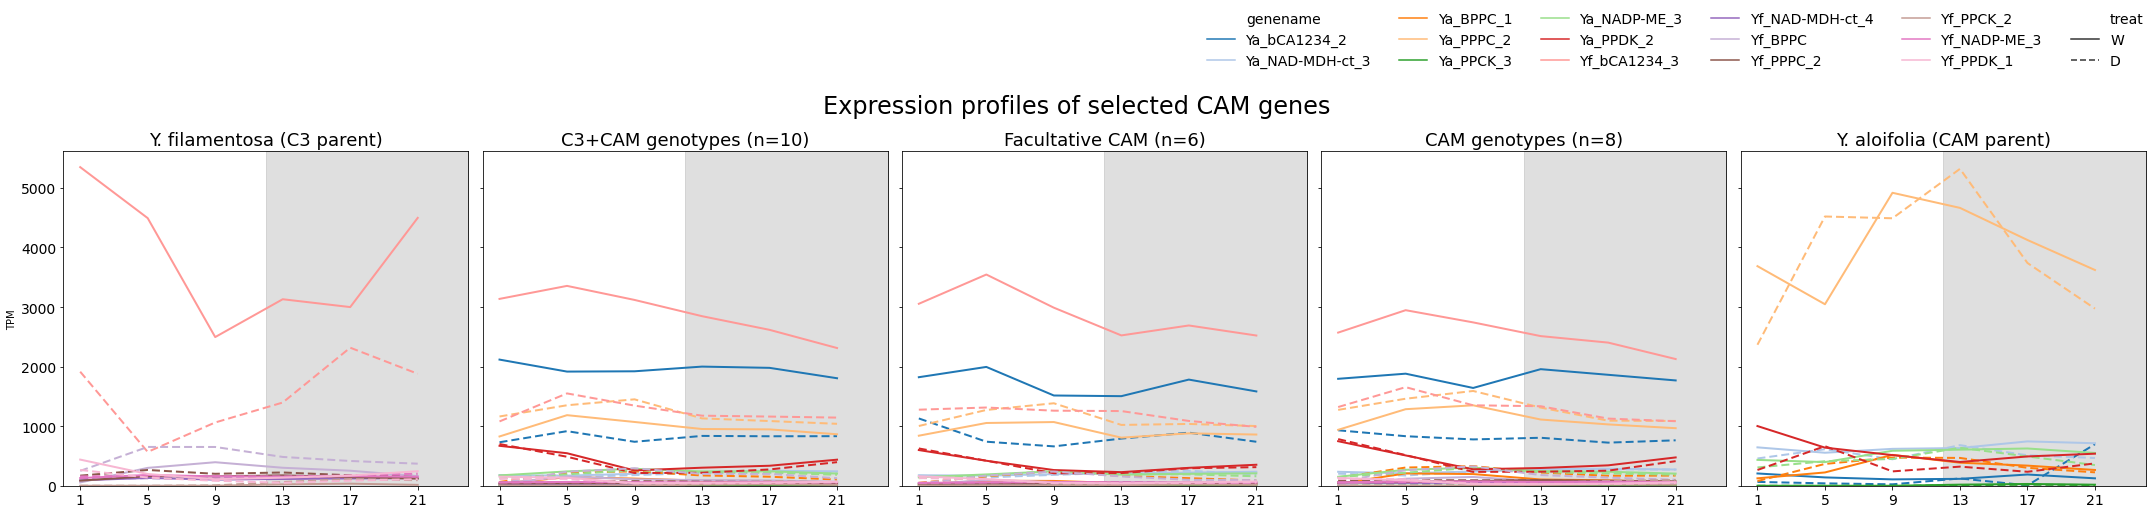

In [78]:
plot_genefam_withparents(gids,"Expression profiles of selected CAM genes","geneprof_Wickelletal_fig3")

## May 13, 2026: Re-plot gene families with colormap adjustment

In [82]:
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [89]:
# adjust stylemap function
def build_family_stylemaps(genefam, yfpal="copper",yapal="winter",camdf=camannot):

    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    genes = fam["gene_abbr_unique"].unique().tolist()
    yfgenes = [i for i in genes if i.startswith("Yf")]
    yagenes = [i for i in genes if i.startswith("Ya")]

    yf_palette = sns.color_palette(yfpal, n_colors=max(len(yfgenes), 3))
    ya_palette = sns.color_palette(yapal, n_colors=max(len(yagenes), 3))
    color_map = {**dict(zip(yfgenes, yf_palette)), **dict(zip(yagenes,ya_palette))}

    # treatment line styles
    treat_map = {
        "W": "",
        "D": (4, 2)
    }

    return color_map, treat_map

In [91]:
def plot_genefam_withparents(genefam, d="./", save=True, log=False):

    # load data
    yaplot = plottpm_genefamily(yatpm, genefam, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, genefam, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, genefam, add_phys=True)

    # physiology groups
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # style maps
    color_map, treat_map = build_family_stylemaps(genefam)

    # figure
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(30, 6),
        sharey=True
    )

    plot_profile(yfplot, ax[0],
                 "Y. filamentosa (C3 parent)",
                 color_map, treat_map, log, 18)

    plot_profile(c3, ax[1],
                 f"C3+CAM genotypes (n={c3gt})",
                 color_map, treat_map, log, 18)

    plot_profile(fac, ax[2],
                 f"Facultative CAM (n={facgt})",
                 color_map, treat_map, log, 18)

    plot_profile(cam, ax[3],
                 f"CAM genotypes (n={camgt})",
                 color_map, treat_map, log, 18)

    plot_profile(yaplot, ax[4],
                 "Y. aloifolia (CAM parent)",
                 color_map, treat_map, log, 18)

    # unify y-axis
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # legend from middle panel
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1, 1.1),
        ncol=min(len(labels), 6),
        fontsize=14,
        frameon=False
    )

    plt.suptitle(genefam, fontsize=24)
    fig.tight_layout()

    if save:
        base = os.path.join(d, f"{genefam}_profiles_by_treatment")
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

In [92]:
def plottpm_genefamily(tpm, genefam, camdf=camannot, add_phys=True):

    fam = camdf[camdf["gene_abbr"] == genefam].copy()

    genes = [g for g in fam["GeneID"].unique() if g in tpm.columns]

    if len(genes) == 0:
        return pd.DataFrame()

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    namedict = fam.set_index("GeneID")["gene_abbr_unique"].to_dict()
    subdict  = fam.set_index("GeneID")["subgenome"].to_dict()

    plong["genename"] = plong["GeneID"].map(namedict)
    plong["subgenome"] = plong["GeneID"].map(subdict)

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong

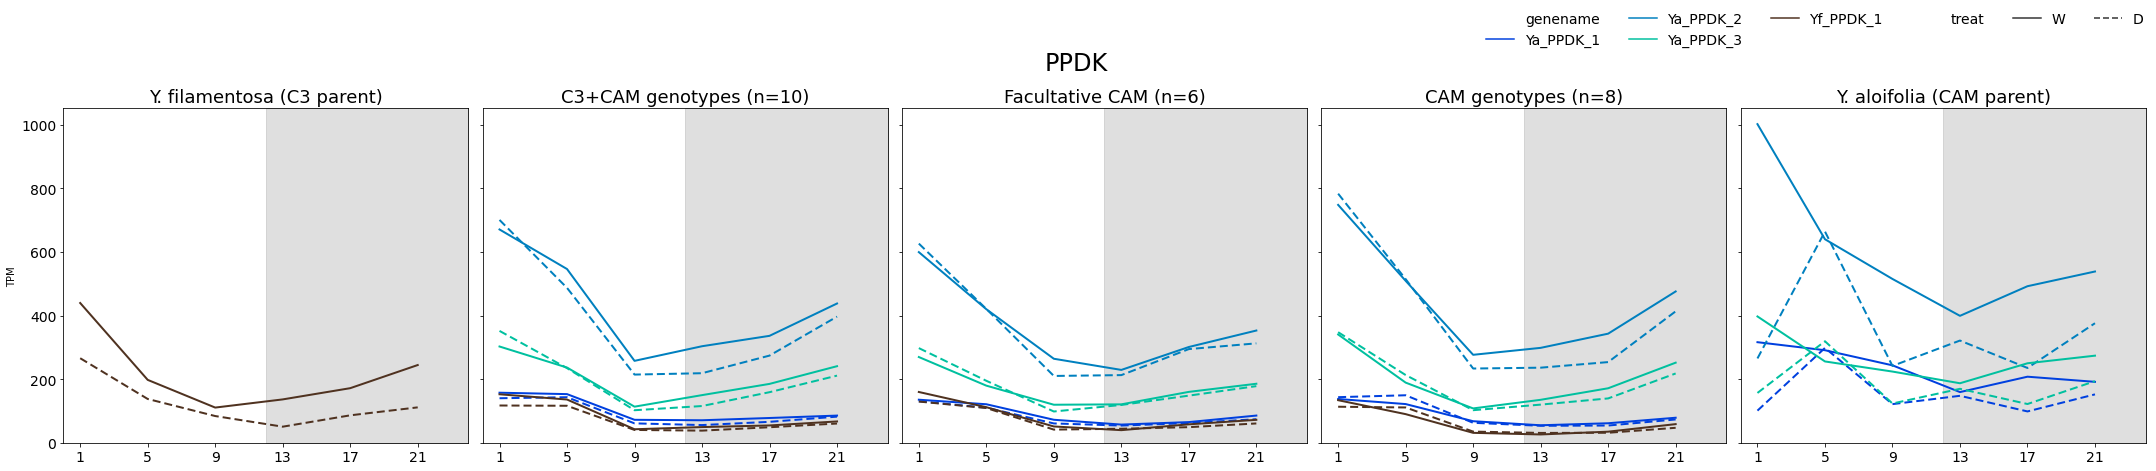

In [93]:
plot_genefam_withparents("PPDK")

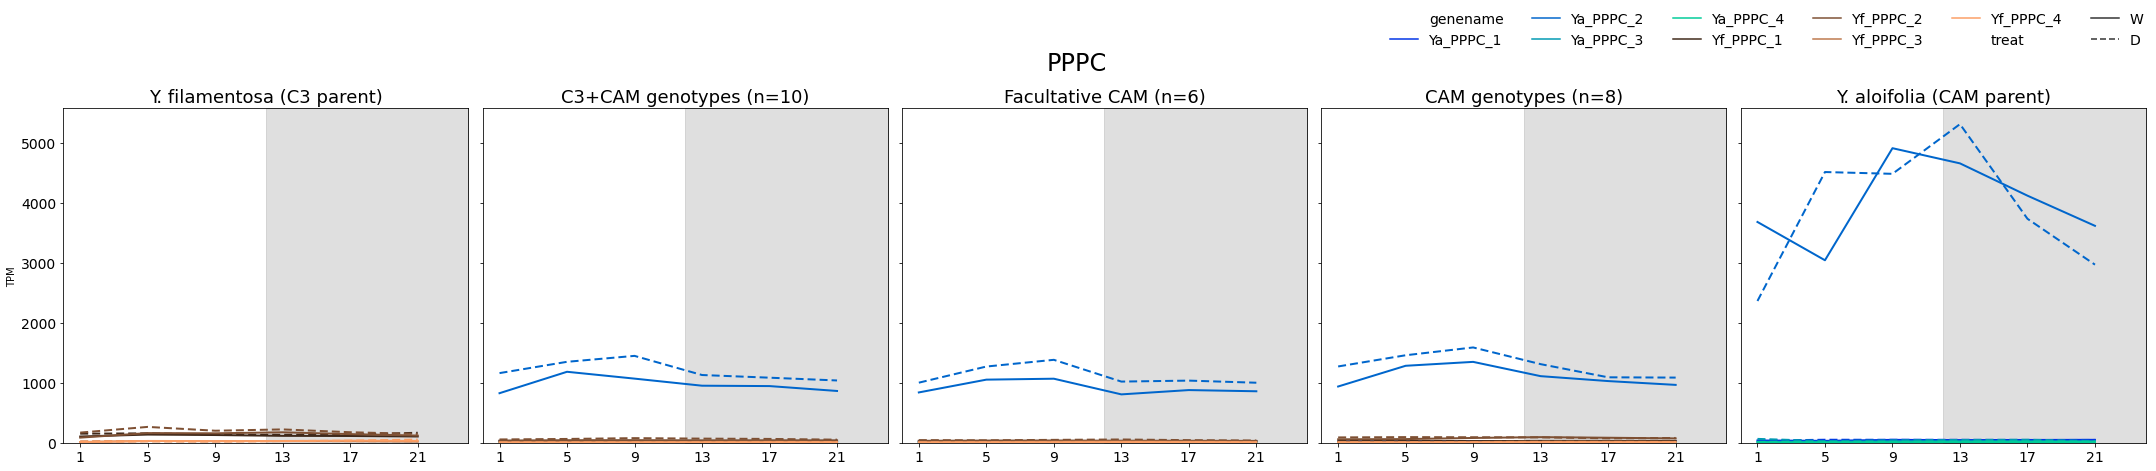

In [94]:
plot_genefam_withparents("PPPC")

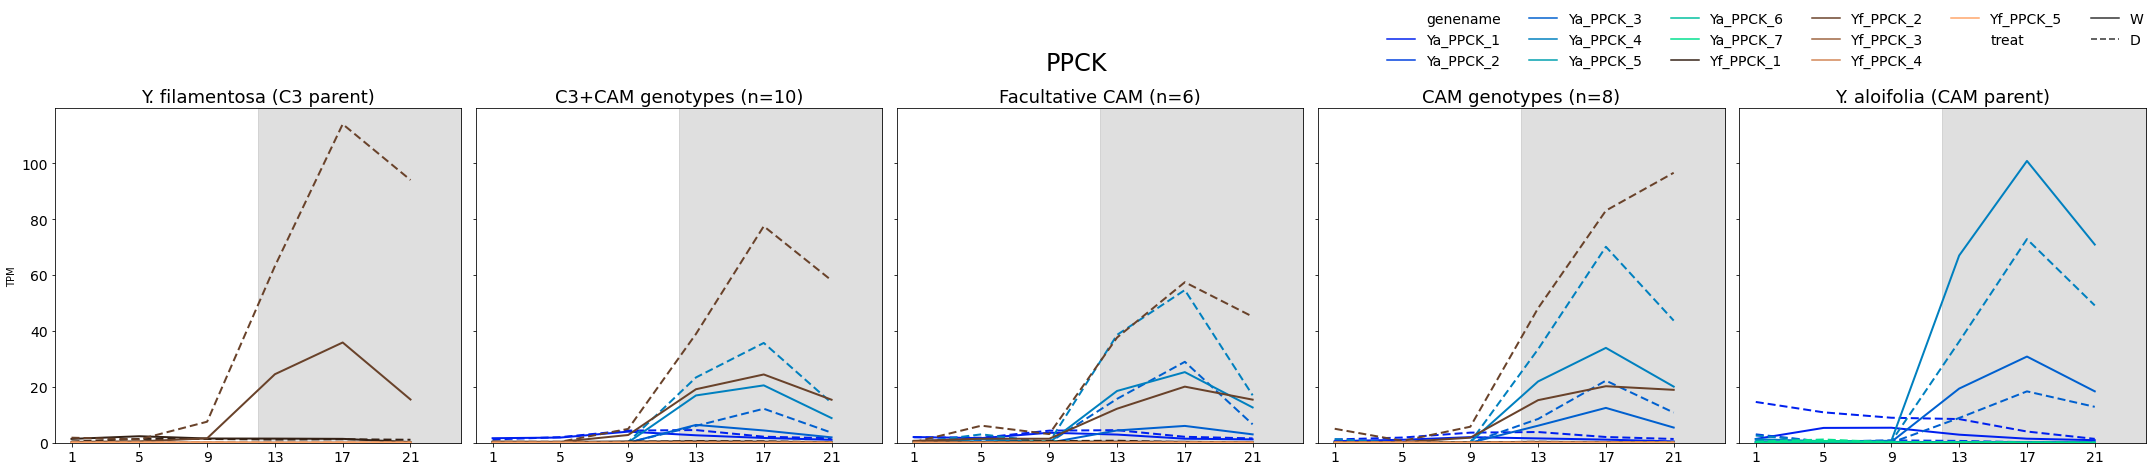

In [95]:
plot_genefam_withparents("PPCK")

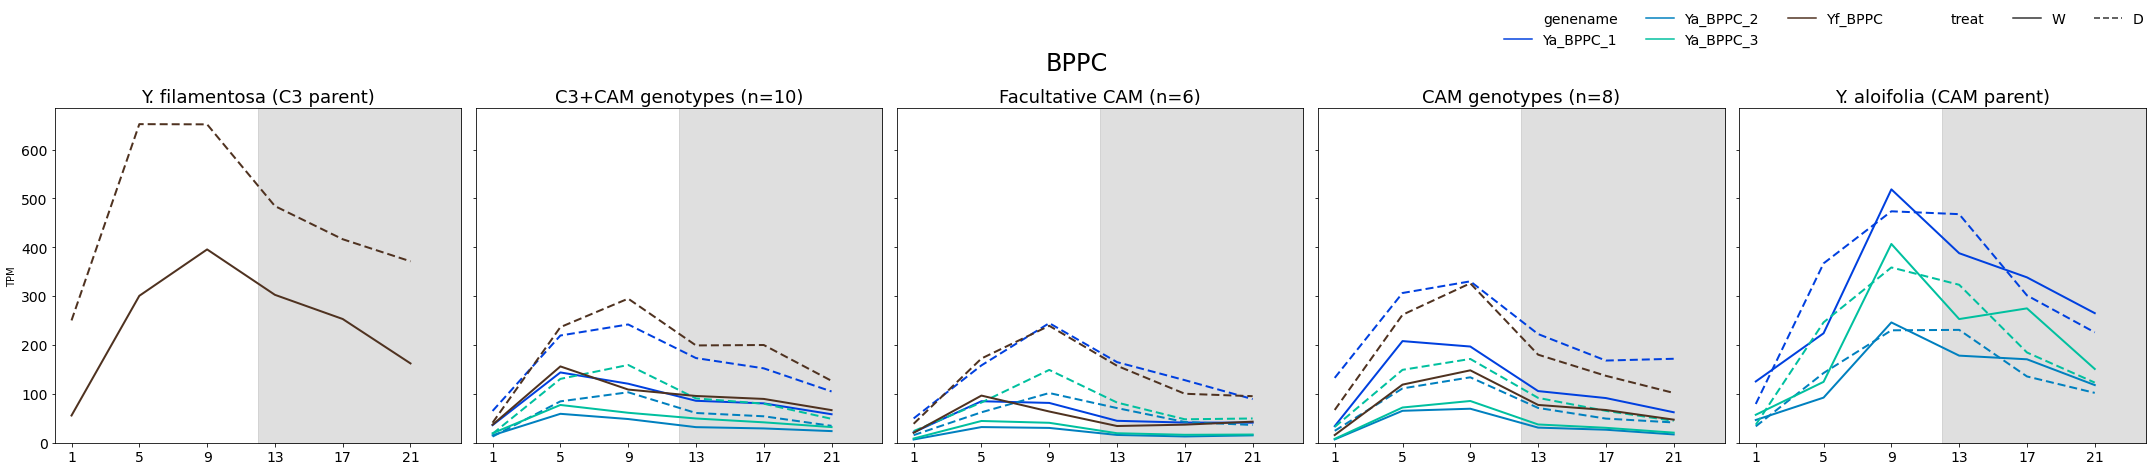

In [96]:
plot_genefam_withparents("BPPC")

In [98]:
camannot["gene_abbr"].unique()

array(['bCA1234', 'bCA5', 'NAD-MDH-cp', 'NAD-MDH-ct', 'NADP-MDH', 'BPPC',
       'PPPC', 'PPCK', 'NAD-ME', 'NADP-ME', 'PEPCK', 'PPDK'], dtype=object)

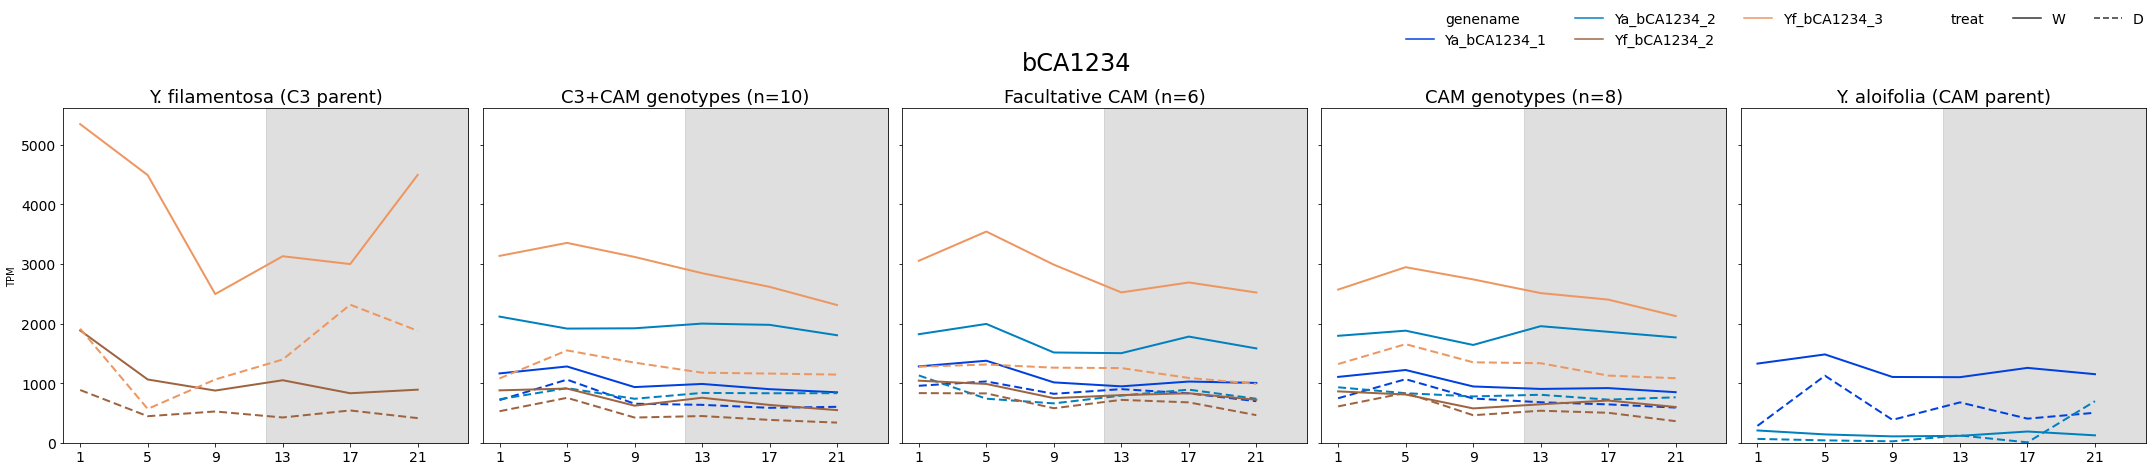

In [99]:
plot_genefam_withparents("bCA1234")

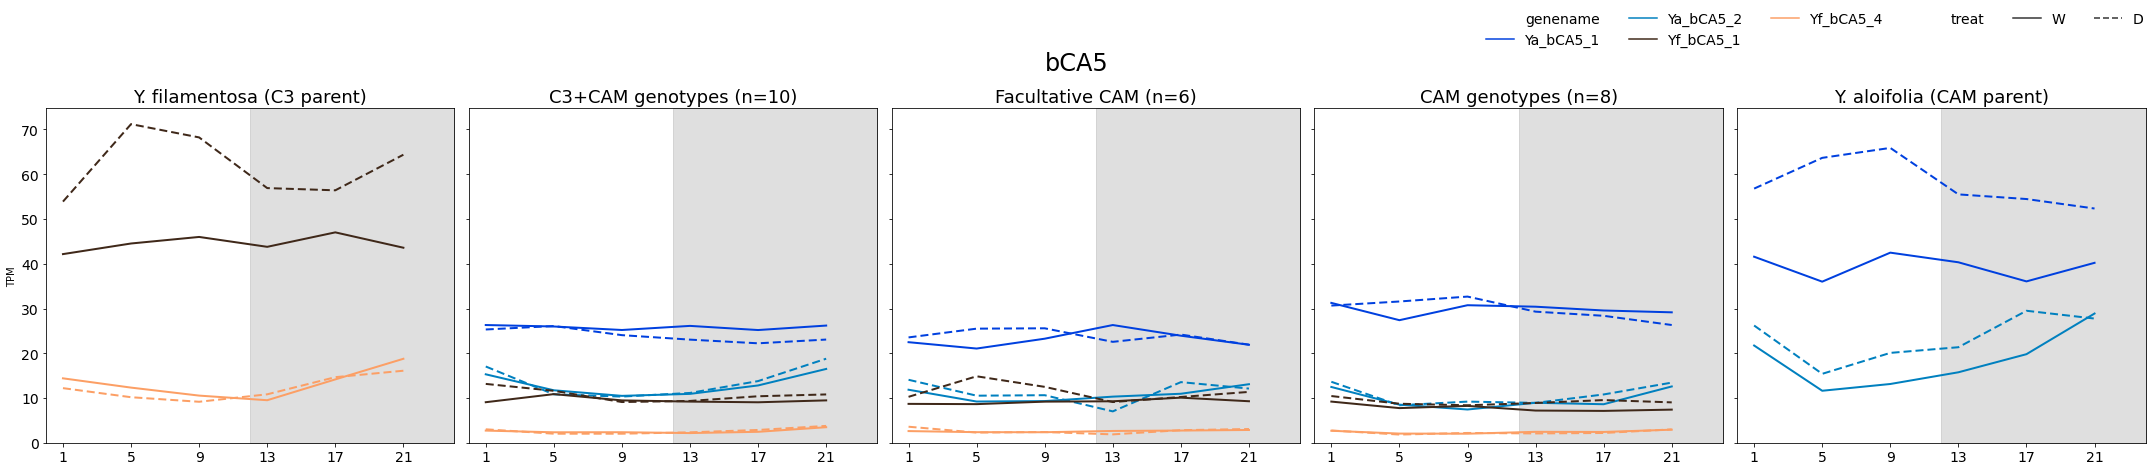

In [100]:
plot_genefam_withparents("bCA5")

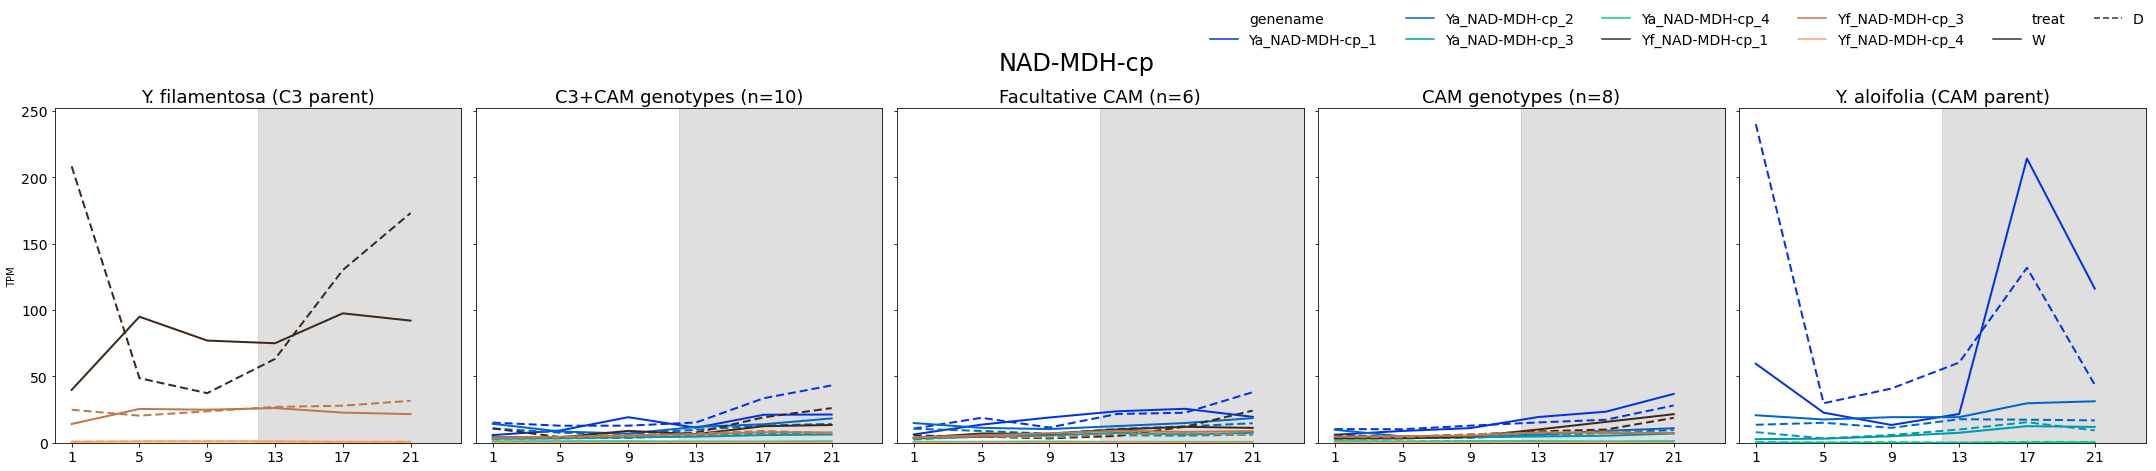

In [101]:
plot_genefam_withparents("NAD-MDH-cp")

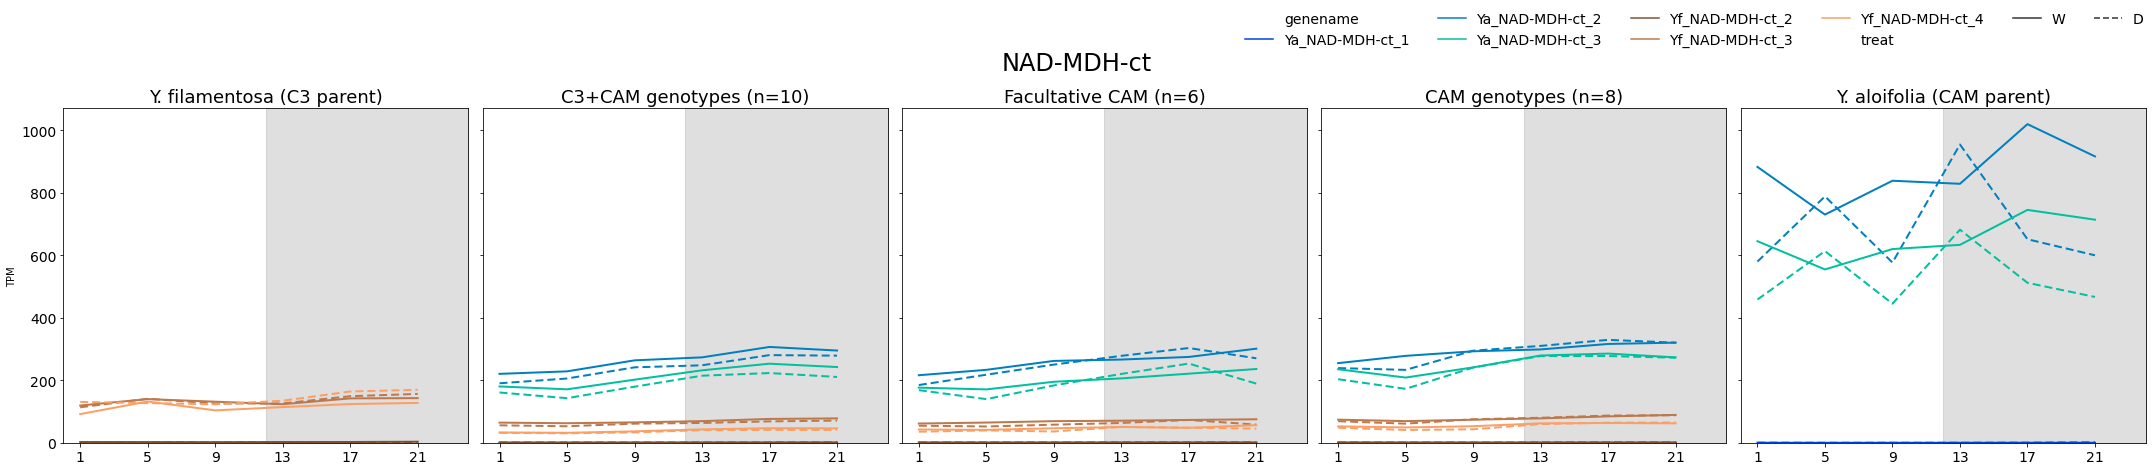

In [102]:
plot_genefam_withparents("NAD-MDH-ct")

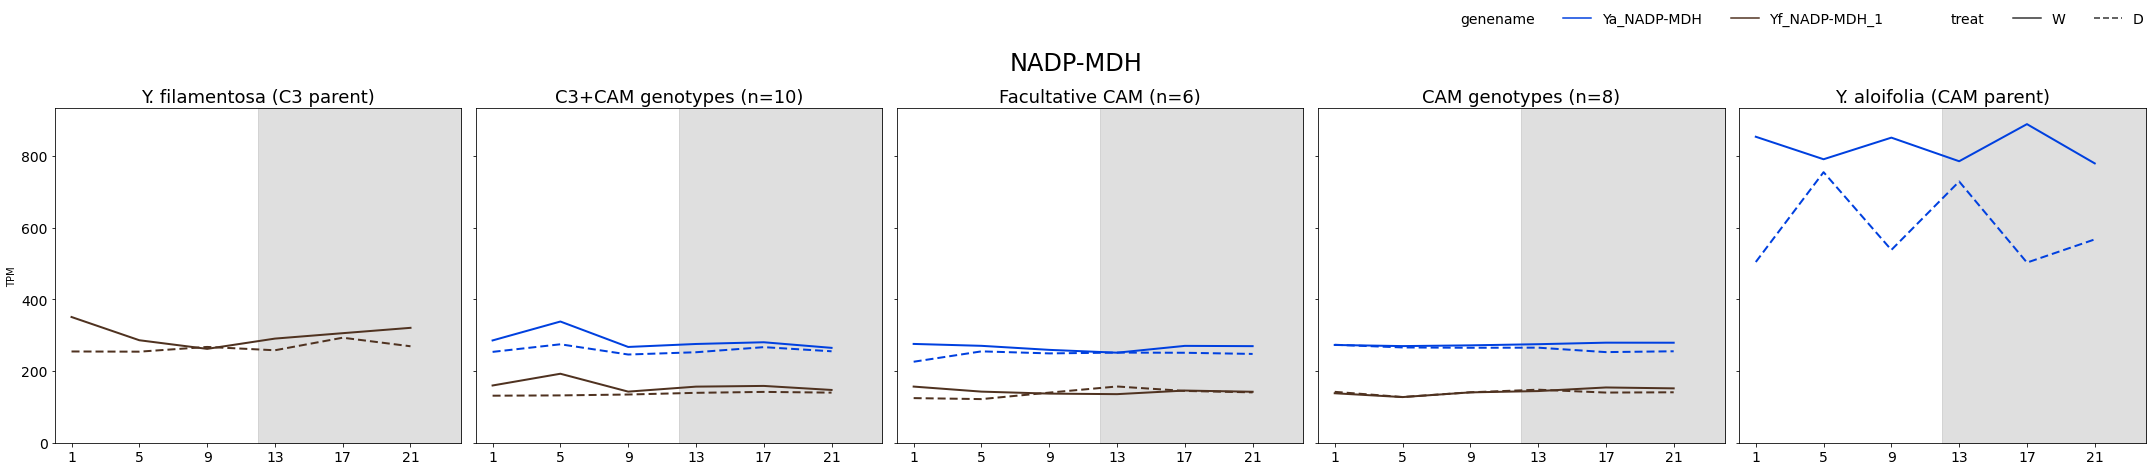

In [103]:
plot_genefam_withparents("NADP-MDH")

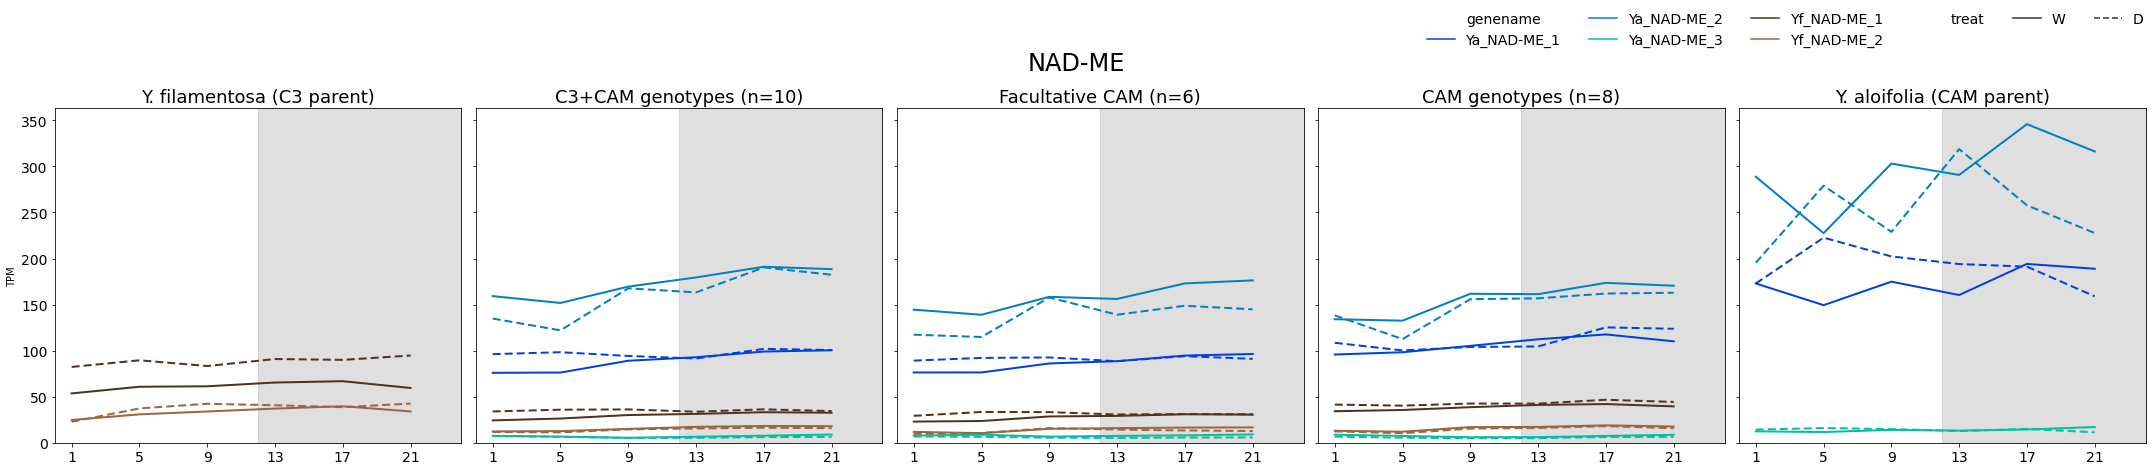

In [104]:
plot_genefam_withparents("NAD-ME")

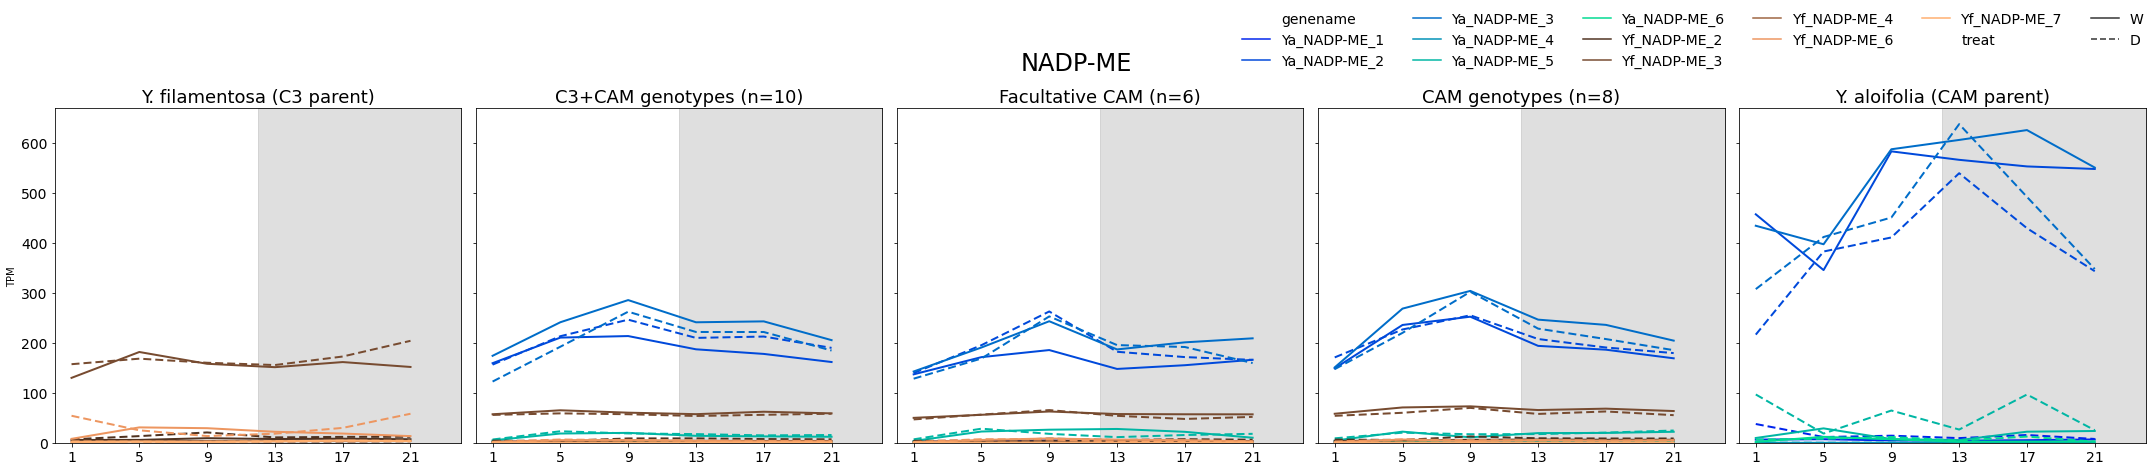

In [105]:
plot_genefam_withparents("NADP-ME")

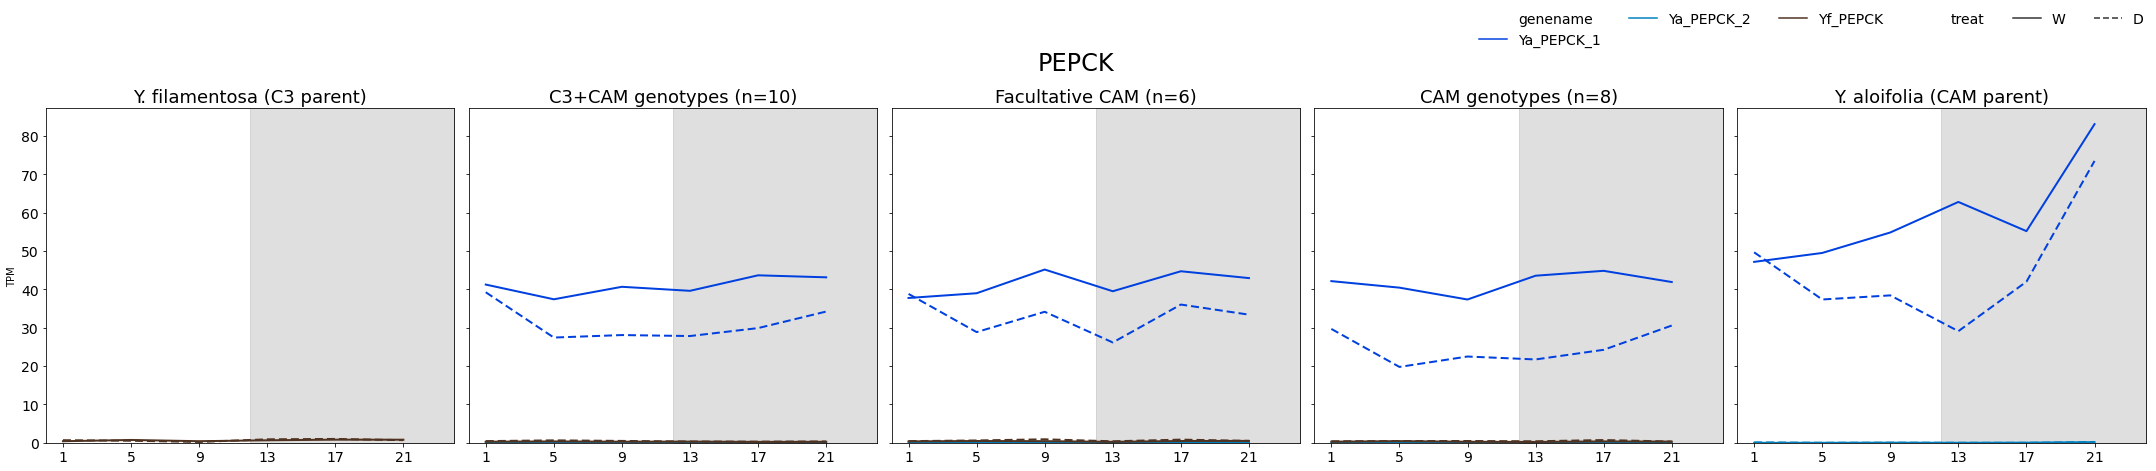

In [106]:
plot_genefam_withparents("PEPCK")